# 07. Урок. Часть 1. Стат критерии

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from scipy.stats import bernoulli
from scipy.stats import median_test
from scipy.stats import chisquare
from scipy.stats import ks_2samp
from scipy.stats import chi2
from scipy.stats import percentileofscore
#from scipy.stats import chi2_contingency
#from statsmodels.stats.weightstats import ttest_ind as sm_ttest_ind
from statsmodels.stats.power import tt_ind_solve_power
from statsmodels.stats.proportion import proportion_confint
from scipy.stats  import gaussian_kde

from scipy.stats import bootstrap
from scipy.stats import shapiro

from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

## Структура урока
- Рассмотрим класический t-test на нормальном распределении
- покажем как проверять ошибку alpha и beta и то что критерий работает
- "испортим" данные и посмотрим как ведут себя ошибки первого и второго рода
- рассмотрим вариант с нестандартной метрикой (квантиль) распределения или меру разброса

## Поработаем с классическим t-test

для начала определим нужный все нужные параметры дизайна теста (альфа, бета, MDE а затем размер выборки)

формула размера выборки

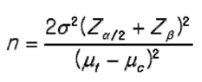


### попробуем провести один модельный тест на разницу средних

Effect size = 0.1
Mean lift = 5.0
Sample size = 1570
----------------
Sample 1 mean =  100.75857624906584
Sample 1 std =  49.72614304274571
----------------
Sample 2 mean =  109.05351374046299
Sample 2 std =  49.19058163050554
----------------
t-test p-value = 2.7472552688267235e-06
t-value = -4.69746436535818


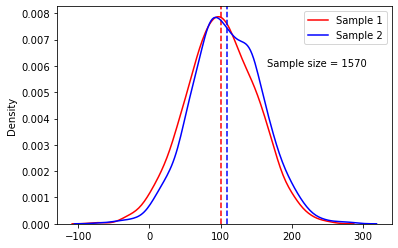

In [2]:
# определим размер выборки и сгенерируем две выборки
# укажем параметры распределения и размер эффекта
alpha = 0.05
beta = 0.2
std = 50
mean = 100
power = 1 - beta
lift = 0.05 # Хотим увидеть 5% изменение в метрику. Tоже самое что чувствительность MDE
effect_size = mean * lift / std # 

print('Effect size =', effect_size)
print('Mean lift =', mean*lift)

# найдем размер выборки
sample_size = int(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, ratio=1))
print('Sample size =', sample_size)

# пример с нормальным распределением
# сгенерируем нормальные данные
sample_1 = np.random.normal(mean, std, sample_size)
sample_2 = np.random.normal(mean*(1+lift), std, sample_size)

# отрисуем графики плотоности распределения по выборкам
sns.kdeplot(sample_1, color = 'red', label="Sample 1")
plt.axvline(sample_1.mean(), color = 'red', linestyle ='--')
sns.kdeplot(sample_2, color = 'blue', label="Sample 2")
plt.axvline(sample_2.mean(), color = 'blue', linestyle ='--')
plt.text(np.quantile(sample_1, 0.9), 0.006, 'Sample size = {}'.format(sample_size))
plt.legend()

# принтуем основные параметры распределения и результаты применения критерия
print('----------------')
print('Sample 1 mean = ' , sample_1.mean())
print('Sample 1 std = ' , sample_1.std())
print('----------------')
print('Sample 2 mean = ' , sample_2.mean())
print('Sample 2 std = ' , sample_2.std())
print('----------------')

# применим статистический критерий
t_stat, p_val = ttest_ind(sample_1, sample_2)
print('t-test p-value =', p_val)
print('t-value =', t_stat)

Все прекрасно в разовом тесте, мы получили то что хотели. Тест отверг нулевую гипотезу. Посмотрим как справляется t-test в многократных тестах.

### Создадим функцию возвращающую графики для оценки эксперимента
В дальнейшем мы будем активно использовать эту визуализацию

In [3]:
def experiment_simulation_plot(alpha, aa_control_group_means, aa_test_group_means, aa_means_diffs_list, aa_stat_list, aa_p_val_list, ab_control_group_means, ab_test_group_means, ab_means_diffs_list, ab_stat_list, ab_p_val_list):   
    '''
    aa_control_group_means - средние полученные по симуляциям в контрольной группе в AA-варианте симуляции
    aa_test_group_means - средние полученные по симуляциям в тестовой группе в AA-варианте симуляции
    aa_means_diffs_list - разница средних в AA-варианте симуляции
    aa_stat_list - значение критерия полученного по симуляциям в AA-варианте симуляции
    aa_p_val_list - p-value  полученные по симуляциям в AA-варианте симуляции
    
    ab_control_group_means - средние полученные по симуляциям в контрольной группе в AB-варианте симуляции 
    ab_test_group_means - средние полученные по симуляциям в тестовой группе в AB-варианте симуляции
    ab_means_diffs_list - разница средних в AB-варианте симуляции
    ab_stat_list - значение критерия полученного по симуляциям в AB-варианте симуляции
    ab_p_val_list - p-value  полученные по симуляциям в AB-варианте симуляции
    
    '''
    
    # рассчитываем 95% доверительные интервалы для полученных численно alpha  и  beta
    alpha_ci = proportion_confint(np.sum(np.array(aa_p_val_list) < alpha), n_iter, alpha=0.05)
    beta_ci = proportion_confint(np.sum(np.array(ab_p_val_list) < alpha), n_iter, alpha=0.05)
    
    # PLOT
    fig, axes = plt.subplots(2, 4, figsize=(15,10))

    ### AA subplots
    ### Первый ряд графиков посвящен АА-симуляциям.
    # График распределения средних в первой и второй выборках. Иллюстрирует тоже самое о чем говорит ЦПТ. 
    sns.kdeplot(ax=axes[0,0], data = aa_control_group_means, color = 'blue') 
    sns.kdeplot(ax=axes[0,0], data = aa_test_group_means, color = 'red')
    axes[0,0].set_title('AA: A|B group mean distribution')
    axes[0,0].axvline(x=np.quantile(aa_control_group_means, 0.5), linestyle = '--', color = 'blue', label = 'control mean')
    axes[0,0].axvline(x=np.quantile(aa_test_group_means, 0.5), linestyle = '--', color = 'red', label = 'test mean')
    axes[0,0].legend(loc='lower right')
       
    # График распределения разницы между средними
    sns.kdeplot(ax=axes[0,1], data = aa_means_diffs_list)
    axes[0,1].axvline(x=0, linestyle = '--', color = 'red', label = 'zero difference')
    axes[0,1].axvline(x=np.quantile(aa_means_diffs_list, alpha/2), linestyle = '--', color = 'grey', label = '95% conf interval for diff')
    axes[0,1].axvline(x=np.quantile(aa_means_diffs_list, 1-alpha/2), linestyle = '--', color = 'grey')
    axes[0,1].set_title('AA: Means diffs distribution')
    axes[0,1].legend(loc='lower right')

    # график распределения значения стат критерия. t-статистика для t-теста
    sns.kdeplot(ax=axes[0,2], data = aa_stat_list)
    axes[0,2].set_title('AA: stats distribution')
    
    # график распределения p-value 
    sns.kdeplot(ax=axes[0,3], data = aa_p_val_list)
    axes[0,3].set_title('AA: p-values distribution')
    axes[0,3].axvline(x=alpha, linestyle = '--', color = 'red', label = 'alpha')
    axes[0,3].axvline(x=np.quantile(aa_p_val_list, 0.8), linestyle = '--', color = 'blue', label = '80% quantile for p-value')
    axes[0,3].legend(loc='lower right')

    ### AB subplots
    ### второй ряд графиков посвящен АБ-симуляциям
    # график распределения средних в первой и второй выборках. Иллюстрирует тоже самое о чем говорит ЦПТ 
    sns.kdeplot(ax=axes[1,0], data = ab_control_group_means, color = 'blue')
    sns.kdeplot(ax=axes[1,0], data = ab_test_group_means, color = 'red')
    axes[1,0].set_title('AB: A|B group mean distribution')
    axes[1,0].axvline(x=np.quantile(ab_control_group_means, 0.5), linestyle = '--', color = 'blue', label = 'control mean')
    axes[1,0].axvline(x=np.quantile(ab_test_group_means, 0.5), linestyle = '--', color = 'red', label = 'test mean')
    axes[1,0].legend(loc='lower right')

    # график распределения разницы между средними
    sns.kdeplot(ax=axes[1,1], data = ab_means_diffs_list)
    axes[1,1].axvline(x=0, linestyle = '--', color = 'red', label = 'zero difference')
    axes[1,1].axvline(x=np.quantile(ab_means_diffs_list, alpha/2), linestyle = '--', color = 'grey', label = '95% conf interval for diff')
    axes[1,1].axvline(x=np.quantile(ab_means_diffs_list, 1-alpha/2), linestyle = '--', color = 'grey')
    axes[1,1].set_title('AB: Means diffs distribution')
    axes[1,1].legend(loc='lower right')

    # график распределения значения стат критерия. t-статистика для t-теста
    sns.kdeplot(ax=axes[1,2], data = ab_stat_list)
    axes[1,2].set_title('AB: stats distribution')
    
    # график распределения p-value 
    sns.kdeplot(ax=axes[1,3], data = ab_p_val_list)
    axes[1,3].set_title('AB: p-values distribution')
    axes[1,3].axvline(x=alpha, linestyle = '--', color = 'red', label = 'alpha')
    axes[1,3].axvline(x=np.quantile(ab_p_val_list, 0.8), linestyle = '--', color = 'blue', label = '80% quantile for p-value')
    axes[1,3].legend(loc='lower right')

    # принтуем ключевые метрики
    print('Median means lift for AA simulation = ', np.median(aa_means_diffs_list))
    print('Alpha(FPR) = ', np.sum(np.array(aa_p_val_list) < alpha) / n_iter)
    print('Alpha 95% CI:', alpha_ci)
    print('Median means lift for AB simulation = ', np.median(ab_means_diffs_list))
    print('Power(TPR) = ', np.sum(np.array(ab_p_val_list) < alpha) / n_iter)
    print('Beta 95% CI:', beta_ci)

# Проверяем t-test на АА и АБ симуляциях

Effect size = 0.1
Estimated absolute effect = 5.0
Number of simulations =  1000
Sample size =  1570
Median means lift for AA simulation =  0.04273734109353455
Alpha(FPR) =  0.057
Alpha 95% CI: (0.042630509644697556, 0.07136949035530245)
Median means lift for AB simulation =  5.009745176409581
Power(TPR) =  0.81
Beta 95% CI: (0.785685384796283, 0.8343146152037171)


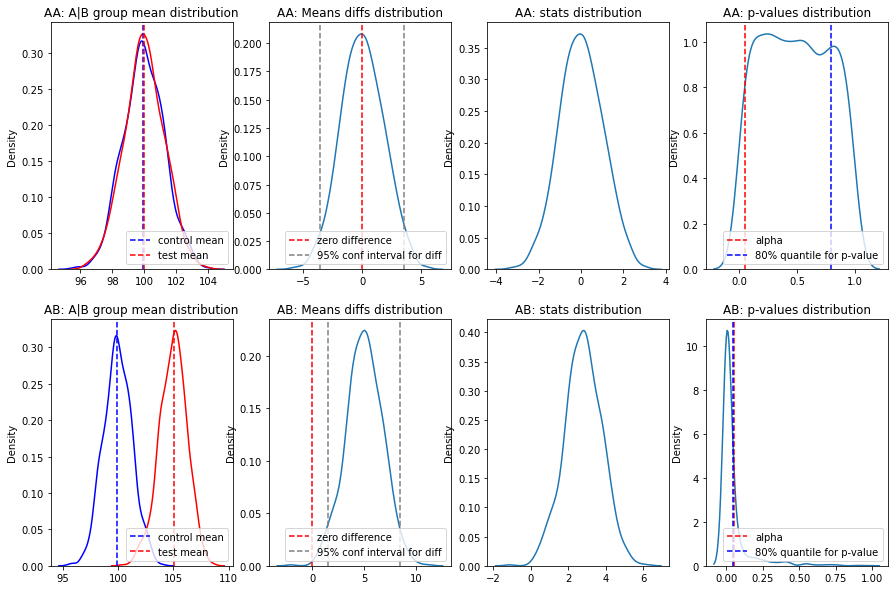

In [4]:
# определим дизайн теста
alpha = 0.05
beta = 0.2
std = 50
mean = 100
power = 1 - beta
rel_lift = 0.05
abs_lift = mean*rel_lift #
effect_size = abs_lift / std

print('Effect size =', effect_size)
print('Estimated absolute effect =', abs_lift)

n_iter = 1000
print('Number of simulations = ', n_iter)

# находим размер выборки
sample_size = int(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, ratio=1))
print('Sample size = ', sample_size)

# создаем пустые листы, которые будут заполняться нужными значениями по мере работы цикла
aa_control_group_means = []
aa_test_group_means = []
ab_control_group_means = []
ab_test_group_means = []

aa_p_val_list = []
aa_t_stat_list = []
aa_means_diffs_list = []

ab_p_val_list = []
ab_t_stat_list = []
ab_means_diffs_list = []

# запускаем цикл многократной проверки (n_iter раз) разницы средних между двумя нормальными рапределениями

for i in range(n_iter):
    # генерируем 3 выборки одну тестовую и две контрольных. При этом эффект добавляем только в одной контрольной
    sample_1 = np.random.normal(mean, std, sample_size)
    sample_2_zero_effect = np.random.normal(mean*(1+0), std, sample_size) #
    sample_2_with_effect = np.random.normal(mean*(1+rel_lift), std, sample_size) # добавляем эффект
    
    aa_control_group_means.append(sample_1.mean())
    aa_test_group_means.append(sample_2_zero_effect.mean())
    
    ab_control_group_means.append(sample_1.mean())
    ab_test_group_means.append(sample_2_with_effect.mean())

    aa_means_diff = sample_2_zero_effect.mean() - sample_1.mean()
    ab_means_diff = sample_2_with_effect.mean() - sample_1.mean()
    
    aa_t_stat, aa_p_val = ttest_ind(sample_2_zero_effect, sample_1)
    ab_t_stat, ab_p_val = ttest_ind(sample_2_with_effect, sample_1)
    
    aa_p_val_list.append(aa_p_val)
    ab_p_val_list.append(ab_p_val)
    
    aa_t_stat_list.append(aa_t_stat)
    ab_t_stat_list.append(ab_t_stat)
    
    aa_means_diffs_list.append(aa_means_diff)
    ab_means_diffs_list.append(ab_means_diff)
    
# рисуем график
experiment_simulation_plot(alpha = 0.05,
                           aa_control_group_means = aa_control_group_means,
                           aa_test_group_means = aa_test_group_means,
                           aa_means_diffs_list = aa_means_diffs_list,
                           aa_stat_list = aa_t_stat_list,
                           aa_p_val_list = aa_p_val_list,
                           ab_control_group_means = ab_control_group_means,
                           ab_test_group_means = ab_test_group_means,
                           ab_means_diffs_list = ab_means_diffs_list,
                           ab_stat_list = ab_t_stat_list,
                           ab_p_val_list = ab_p_val_list)

Как мы видим на 1000 симмуляциях t-test справляется хорошо. Нужные альфа и бета выдерживаются. Критерий работает корректно.

#### Посмотрим как справляется с таким кейсом тест Манна-Уитни

Effect size = 0.1
Estimated absolute effect = 5.0
Number of simulations =  1000
Sample size =  1570
Median means lift for AA simulation =  0.0649596772719434
Alpha(FPR) =  0.043
Alpha 95% CI: (0.03042701817664624, 0.055572981823353754)
Median means lift for AB simulation =  4.893820377819942
Power(TPR) =  0.788
Beta 95% CI: (0.7626674370670894, 0.8133325629329107)


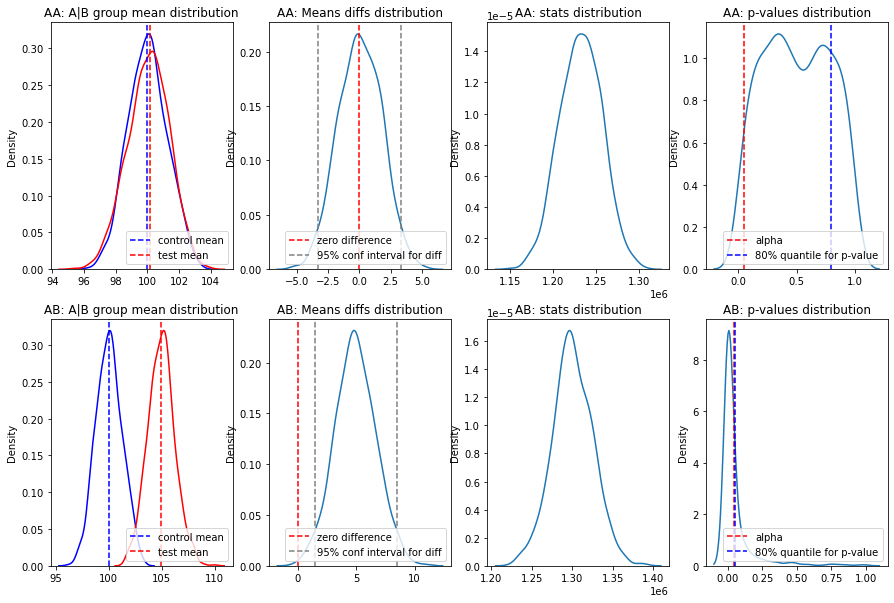

In [5]:
# определим дизайн теста
alpha = 0.05
beta = 0.2
std = 50
mean = 100
power = 1 - beta
rel_lift = 0.05
abs_lift = mean*rel_lift #
effect_size = abs_lift / std

print('Effect size =', effect_size)
print('Estimated absolute effect =', abs_lift)

n_iter = 1000
print('Number of simulations = ', n_iter)

sample_size = int(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, ratio=1))
print('Sample size = ', sample_size)

aa_control_group_means = []
aa_test_group_means = []
ab_control_group_means = []
ab_test_group_means = []

aa_p_val_list = []
aa_u_stat_list = []
aa_means_diffs_list = []

ab_p_val_list = []
ab_u_stat_list = []
ab_means_diffs_list = []

for i in range(n_iter):
    sample_1 = np.random.normal(mean, std, sample_size)
    sample_2_zero_effect = np.random.normal(mean*(1+0), std, sample_size)
    sample_2_with_effect = np.random.normal(mean*(1+rel_lift), std, sample_size)
    
    aa_control_group_means.append(sample_1.mean())
    aa_test_group_means.append(sample_2_zero_effect.mean())
    
    ab_control_group_means.append(sample_1.mean())
    ab_test_group_means.append(sample_2_with_effect.mean())

    aa_means_diff = sample_2_zero_effect.mean() - sample_1.mean()
    ab_means_diff = sample_2_with_effect.mean() - sample_1.mean()
    
    aa_u_stat, aa_p_val = mannwhitneyu(sample_2_zero_effect, sample_1)
    ab_u_stat, ab_p_val = mannwhitneyu(sample_2_with_effect, sample_1)
    
    aa_p_val_list.append(aa_p_val)
    ab_p_val_list.append(ab_p_val)
    
    aa_u_stat_list.append(aa_u_stat)
    ab_u_stat_list.append(ab_u_stat)
    
    aa_means_diffs_list.append(aa_means_diff)
    ab_means_diffs_list.append(ab_means_diff)
    
experiment_simulation_plot(alpha = 0.05,
                           aa_control_group_means = aa_control_group_means,
                           aa_test_group_means = aa_test_group_means,
                           aa_means_diffs_list = aa_means_diffs_list,
                           aa_stat_list = aa_u_stat_list,
                           aa_p_val_list = aa_p_val_list,
                           ab_control_group_means = ab_control_group_means,
                           ab_test_group_means = ab_test_group_means,
                           ab_means_diffs_list = ab_means_diffs_list,
                           ab_stat_list = ab_u_stat_list,
                           ab_p_val_list = ab_p_val_list)

Как видим на нормальных данных тест Манна-Уитни справляется не хуже, чем t-test. Возможно только чуть подольше. 

# Посмотрим как работает t-test с рядом ухудшений
- выбросы
- разная дисперсия
- ненормальные исходные данные

### Добавим выбросы в данные  и прогоним через t-test

Effect size = 0.1
Estimated absolute effect = 5.0
Number of simulations =  1000
Sample size =  1570
Number of outliers =  10
Median means lift for AA simulation =  2.614283846626492
Alpha(FPR) =  0.232
Alpha 95% CI: (0.20583789444949058, 0.25816210555050945)
Median means lift for AB simulation =  -2.461554215167226
Power(TPR) =  0.207
Beta 95% CI: (0.18188866178644073, 0.23211133821355925)


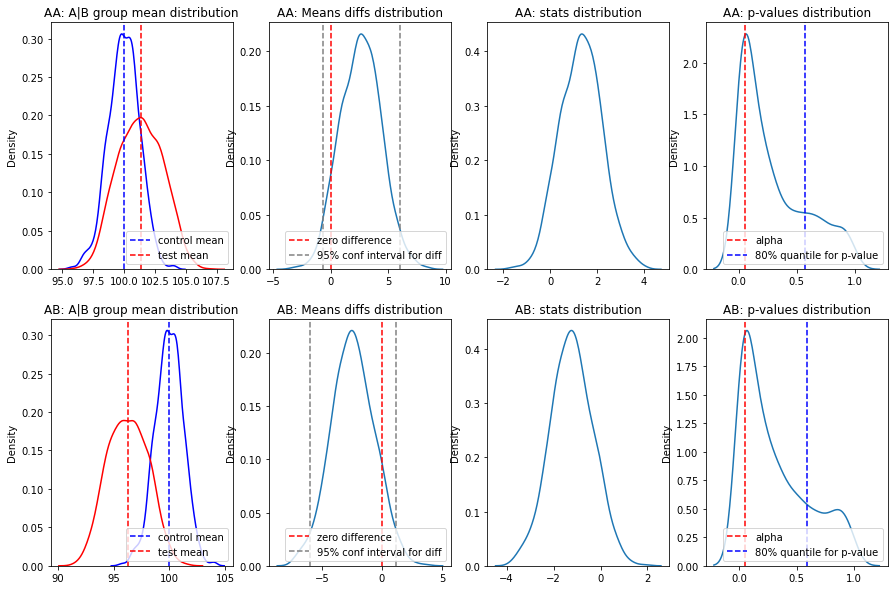

In [9]:
# определим дизайн теста
alpha = 0.05
beta = 0.2
std = 50
mean = 100
power = 1 - beta
rel_lift = 0.05
abs_lift = mean*rel_lift #
effect_size = abs_lift / std

print('Effect size =', effect_size)
print('Estimated absolute effect =', abs_lift)

n_iter = 1000
print('Number of simulations = ', n_iter)

sample_size = int(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, ratio=1))
print('Sample size = ', sample_size)

n_outliers = 10 # добавляем 10 наблюдений из другого распределения
print('Number of outliers = ', n_outliers)

aa_control_group_means = []
aa_test_group_means = []
ab_control_group_means = []
ab_test_group_means = []

aa_p_val_list = []
aa_t_stat_list = []
aa_means_diffs_list = []

ab_p_val_list = []
ab_t_stat_list = []
ab_means_diffs_list = []

for i in range(n_iter):
    sample_1 = np.random.normal(mean, std, sample_size)    
    sample_2_zero_effect = np.random.normal(mean*(1+0), std, sample_size-n_outliers)
    sample_2_with_effect = np.random.normal(mean*(1-rel_lift), std, sample_size-n_outliers)

    outliers = np.random.normal(5*mean, 3*std, size=n_outliers) # сгенерируем нужно количество выбросов из другого, аномального распределния
    
    sample_2_zero_effect_outliers = np.concatenate((sample_2_zero_effect, outliers), axis = None)
    sample_2_with_effect_outliers = np.concatenate((sample_2_with_effect, outliers), axis = None)

    aa_control_group_means.append(sample_1.mean())
    aa_test_group_means.append(sample_2_zero_effect_outliers.mean())
    ab_control_group_means.append(sample_1.mean())
    ab_test_group_means.append(sample_2_with_effect_outliers.mean())
    
    aa_means_diff = sample_2_zero_effect_outliers.mean() - sample_1.mean()
    ab_means_diff = sample_2_with_effect_outliers.mean() - sample_1.mean()
    
    aa_t_stat, aa_p_val = ttest_ind(sample_2_zero_effect_outliers, sample_1)
    ab_t_stat, ab_p_val = ttest_ind(sample_2_with_effect_outliers, sample_1)
    
    aa_p_val_list.append(aa_p_val)
    ab_p_val_list.append(ab_p_val)
    
    aa_t_stat_list.append(aa_t_stat)
    ab_t_stat_list.append(ab_t_stat)
    
    aa_means_diffs_list.append(aa_means_diff)
    ab_means_diffs_list.append(ab_means_diff)
    
    aa_control_group_means.append(sample_1.mean())
    aa_test_group_means.append(sample_2_zero_effect.mean())
    
    ab_control_group_means.append(sample_1.mean())
    ab_test_group_means.append(sample_2_with_effect.mean())
    
experiment_simulation_plot(alpha = 0.05,
                           aa_control_group_means = aa_control_group_means,
                           aa_test_group_means = aa_test_group_means,
                           aa_means_diffs_list = aa_means_diffs_list,
                           aa_stat_list = aa_t_stat_list,
                           aa_p_val_list = aa_p_val_list,
                           ab_control_group_means = ab_control_group_means,
                           ab_test_group_means = ab_test_group_means,
                           ab_means_diffs_list = ab_means_diffs_list,
                           ab_stat_list = ab_t_stat_list,
                           ab_p_val_list = ab_p_val_list)

Как видно из симуляций добавление даже относительно небольшого кол-ва выбросов повышает ошибку первого рода в t-test. При этом мощность вырастает, т.к. выбросы действуют сонаправленно с эффектом, который мы закладывали. Но это не повод для радости, т.к. в реальности вы не знаете какой реальный эффект дает нововведение и мощность может и значительно упасть, если эффект и выбросы не сонаправленны.

# Проверим починит ли проблему с выбросами тест Манна-Уитни

Effect size = 0.1
Estimated absolute effect = 5.0
Number of simulations =  1000
Sample size =  1570
Number of outliers =  10
Median means lift for AA simulation =  2.570409491015333
Alpha(FPR) =  0.053
Alpha 95% CI: (0.03911451622486782, 0.06688548377513218)
Median means lift for AB simulation =  7.497776766437795
Power(TPR) =  0.792
Beta 95% CI: (0.7668439557901909, 0.8171560442098091)


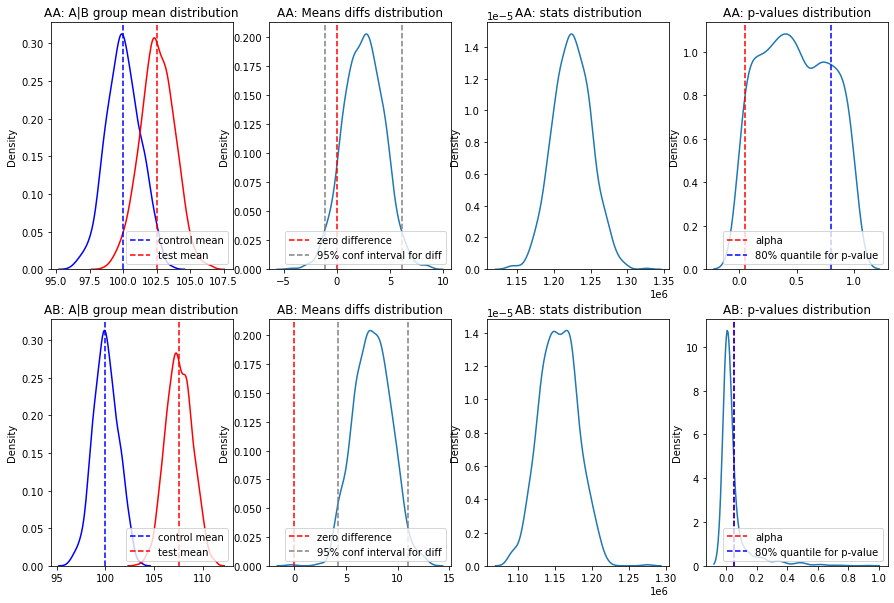

In [14]:
# определим дизайн теста
alpha = 0.05
beta = 0.2
std = 50
mean = 100
power = 1 - beta
rel_lift = 0.05
abs_lift = mean*rel_lift #
effect_size = abs_lift / std

print('Effect size =', effect_size)
print('Estimated absolute effect =', abs_lift)

n_iter = 1000
print('Number of simulations = ', n_iter)

sample_size = int(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, ratio=1))
print('Sample size = ', sample_size)

n_outliers = 10 #int(sample_size*0.005)
print('Number of outliers = ', n_outliers)

aa_control_group_means = []
aa_test_group_means = []
ab_control_group_means = []
ab_test_group_means = []

aa_p_val_list = []
aa_u_stat_list = []
aa_means_diffs_list = []

ab_p_val_list = []
ab_u_stat_list = []
ab_means_diffs_list = []

for i in range(n_iter):
    sample_1 = np.random.normal(mean, std, sample_size)    
    sample_2_zero_effect = np.random.normal(mean*(1+0), std, sample_size-n_outliers)
    sample_2_with_effect = np.random.normal(mean*(1+rel_lift), std, sample_size-n_outliers)

    outliers = np.random.normal(5*mean, 3*std, size=n_outliers)
    
    sample_2_zero_effect_outliers = np.concatenate((sample_2_zero_effect, outliers), axis = None)
    sample_2_with_effect_outliers = np.concatenate((sample_2_with_effect, outliers), axis = None)
    
    aa_control_group_means.append(sample_1.mean())
    aa_test_group_means.append(sample_2_zero_effect_outliers.mean())
    ab_control_group_means.append(sample_1.mean())
    ab_test_group_means.append(sample_2_with_effect_outliers.mean())

    aa_means_diff = sample_2_zero_effect_outliers.mean() - sample_1.mean()
    ab_means_diff = sample_2_with_effect_outliers.mean() - sample_1.mean()
    
    aa_u_stat, aa_p_val = mannwhitneyu(sample_1, sample_2_zero_effect)
    ab_u_stat, ab_p_val = mannwhitneyu(sample_1, sample_2_with_effect)
    
    aa_p_val_list.append(aa_p_val)
    ab_p_val_list.append(ab_p_val)
    
    aa_u_stat_list.append(aa_u_stat)
    ab_u_stat_list.append(ab_u_stat)
    
    aa_means_diffs_list.append(aa_means_diff)
    ab_means_diffs_list.append(ab_means_diff)
    

experiment_simulation_plot(alpha = 0.05,
                           aa_control_group_means = aa_control_group_means,
                           aa_test_group_means = aa_test_group_means,
                           aa_means_diffs_list = aa_means_diffs_list,
                           aa_stat_list = aa_u_stat_list,
                           aa_p_val_list = aa_p_val_list,
                           ab_control_group_means = ab_control_group_means,
                           ab_test_group_means = ab_test_group_means,
                           ab_means_diffs_list = ab_means_diffs_list,
                           ab_stat_list = ab_u_stat_list,
                           ab_p_val_list = ab_p_val_list)

Действительно критерий Манна-Уитни устойчив к появлению выбросов в выборке. И смог вернуться к целевым значениям ошибки первого рода. Это происходит из-за того, что критерий переводит оцениваемую величину в ранговое пространство значений. И там влияние выбросов значительно ослабевает.

# Проверим как ведет себя t-test с НЕнормальным распределением

Часто можно слышать, что t-test не предназначен для работы с НЕнормальными распределением. Давайте проверим это на практике. Рассмотрим экспоненциальное распределение.

Effect size = 0.05
Estimated absolute effect = 5.0
Number of simulations =  1000
Sample size =  6280
Median means lift for AA simulation =  0.021668876847819263
Alpha(FPR) =  0.066
Alpha 95% CI: (0.05061159892832044, 0.08138840107167956)
Median means lift for AB simulation =  4.969203593427544
Power(TPR) =  0.781
Beta 95% CI: (0.7553672226391149, 0.8066327773608851)


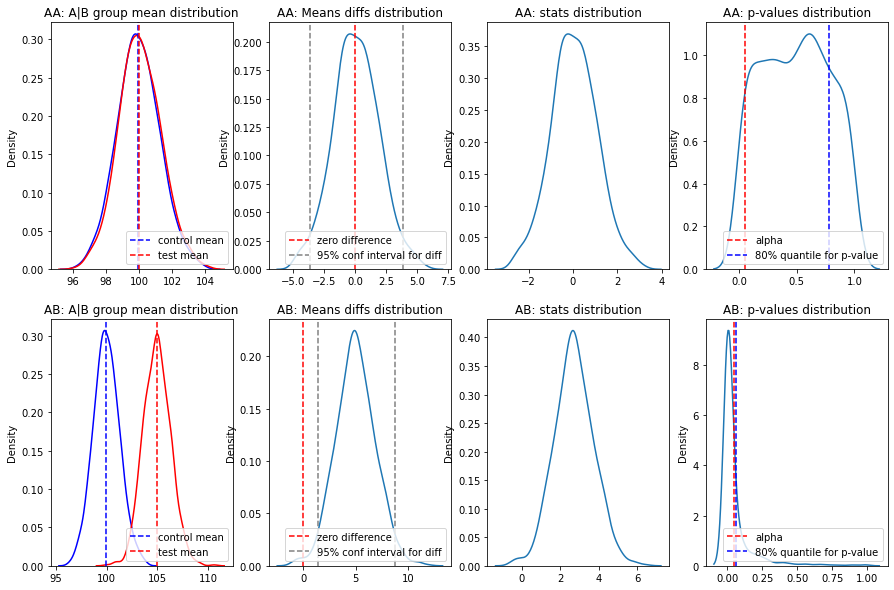

In [15]:
# определим дизайн теста
alpha = 0.05
beta = 0.2

sigma_1 = 100
std = sigma_1
power = 1 - beta
rel_lift = 0.05
abs_lift = sigma_1*rel_lift #
effect_size = abs_lift / std

print('Effect size =', effect_size)
print('Estimated absolute effect =', abs_lift)

n_iter = 1000
print('Number of simulations = ', n_iter)

sample_size = int(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, ratio=1))
#sample_size = 100
print('Sample size = ', sample_size)

aa_control_group_means = []
aa_test_group_means = []
ab_control_group_means = []
ab_test_group_means = []

aa_p_val_list = []
aa_t_stat_list = []
aa_means_diffs_list = []

ab_p_val_list = []
ab_t_stat_list = []
ab_means_diffs_list = []

for i in range(n_iter):
      
    sample_1 = np.random.exponential(scale= sigma_1, size=sample_size)
    sample_2_zero_effect = np.random.exponential(scale= sigma_1+0, size=sample_size)
    sample_2_with_effect = np.random.exponential(scale= sigma_1+sigma_1*rel_lift, size=sample_size)
    
    aa_control_group_means.append(sample_1.mean())
    aa_test_group_means.append(sample_2_zero_effect.mean())
    ab_control_group_means.append(sample_1.mean())
    ab_test_group_means.append(sample_2_with_effect.mean())

    aa_means_diff = sample_2_zero_effect.mean() - sample_1.mean()
    ab_means_diff = sample_2_with_effect.mean() - sample_1.mean()
    
    aa_t_stat, aa_p_val = ttest_ind(sample_2_zero_effect, sample_1)
    ab_t_stat, ab_p_val = ttest_ind(sample_2_with_effect, sample_1)
    
    aa_p_val_list.append(aa_p_val)
    ab_p_val_list.append(ab_p_val)
    
    aa_t_stat_list.append(aa_t_stat)
    ab_t_stat_list.append(ab_t_stat)
    
    aa_means_diffs_list.append(aa_means_diff)
    ab_means_diffs_list.append(ab_means_diff)
    
experiment_simulation_plot(alpha = 0.05,
                           aa_control_group_means = aa_control_group_means,
                           aa_test_group_means = aa_test_group_means,
                           aa_means_diffs_list = aa_means_diffs_list,
                           aa_stat_list = aa_t_stat_list,
                           aa_p_val_list = aa_p_val_list,
                           ab_control_group_means = ab_control_group_means,
                           ab_test_group_means = ab_test_group_means,
                           ab_means_diffs_list = ab_means_diffs_list,
                           ab_stat_list = ab_t_stat_list,
                           ab_p_val_list = ab_p_val_list)

t-test вполне себе прилично справляется с ненормальным распределением

# Посмотрим как справляется с экспоненциальным распределением критерий Манна-Уитни

Effect size = 0.05
Estimated absolute effect = 5.0
Number of simulations =  1000
Sample size =  6280
Median means lift for AA simulation =  -0.09105155876090976
Alpha(FPR) =  0.048
Alpha 95% CI: (0.0347508754149401, 0.061249124585059905)
Median means lift for AB simulation =  4.990034105914091
Power(TPR) =  0.672
Beta 95% CI: (0.6429015638320181, 0.701098436167982)


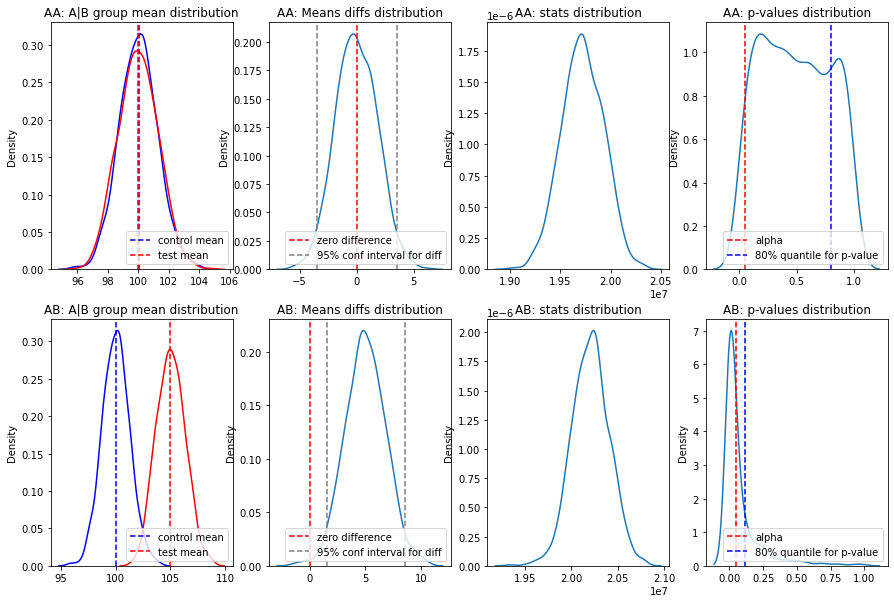

In [16]:
# определим дизайн теста
alpha = 0.05
beta = 0.2

sigma_1 = 100
std = sigma_1
power = 1 - beta
rel_lift = 0.05
abs_lift = sigma_1*rel_lift #
effect_size = abs_lift / std

print('Effect size =', effect_size)
print('Estimated absolute effect =', abs_lift)

n_iter = 1000
print('Number of simulations = ', n_iter)

sample_size = int(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, ratio=1))
print('Sample size = ', sample_size)

aa_control_group_means = []
aa_test_group_means = []
ab_control_group_means = []
ab_test_group_means = []

aa_p_val_list = []
aa_u_stat_list = []
aa_means_diffs_list = []

ab_p_val_list = []
ab_u_stat_list = []
ab_means_diffs_list = []

for i in range(n_iter):
    # создаем выборки 
    sample_1 = np.random.exponential(scale= sigma_1, size=sample_size)
    sample_2_zero_effect = np.random.exponential(scale= sigma_1+0, size=sample_size)
    sample_2_with_effect = np.random.exponential(scale= sigma_1+sigma_1*rel_lift, size=sample_size)

    # рассчитываем нужные метрики
    aa_control_group_means.append(sample_1.mean())
    aa_test_group_means.append(sample_2_zero_effect.mean())
    ab_control_group_means.append(sample_1.mean())
    ab_test_group_means.append(sample_2_with_effect.mean())

    aa_means_diff = sample_2_zero_effect.mean() - sample_1.mean()
    ab_means_diff = sample_2_with_effect.mean() - sample_1.mean()
    
    aa_u_stat, aa_p_val = mannwhitneyu(sample_2_zero_effect, sample_1)
    ab_u_stat, ab_p_val = mannwhitneyu(sample_2_with_effect, sample_1)
    
    aa_p_val_list.append(aa_p_val)
    ab_p_val_list.append(ab_p_val)
    
    aa_u_stat_list.append(aa_u_stat)
    ab_u_stat_list.append(ab_u_stat)
    
    aa_means_diffs_list.append(aa_means_diff)
    ab_means_diffs_list.append(ab_means_diff)
    
experiment_simulation_plot(alpha = 0.05,
                           aa_control_group_means = aa_control_group_means,
                           aa_test_group_means = aa_test_group_means,
                           aa_means_diffs_list = aa_means_diffs_list,
                           aa_stat_list = aa_u_stat_list,
                           aa_p_val_list = aa_p_val_list,
                           ab_control_group_means = ab_control_group_means,
                           ab_test_group_means = ab_test_group_means,
                           ab_means_diffs_list = ab_means_diffs_list,
                           ab_stat_list = ab_u_stat_list,
                           ab_p_val_list = ab_p_val_list)

Критерий Манна-Уитни тоже вполне справляется с экспоненциальным распределением, но проблема в том, что мощность при этом пострадала. По результатам 1000 симуляций 95% доверительный интервал для мощности составляет от 0,64 до 0,7.

<AxesSubplot:ylabel='Density'>

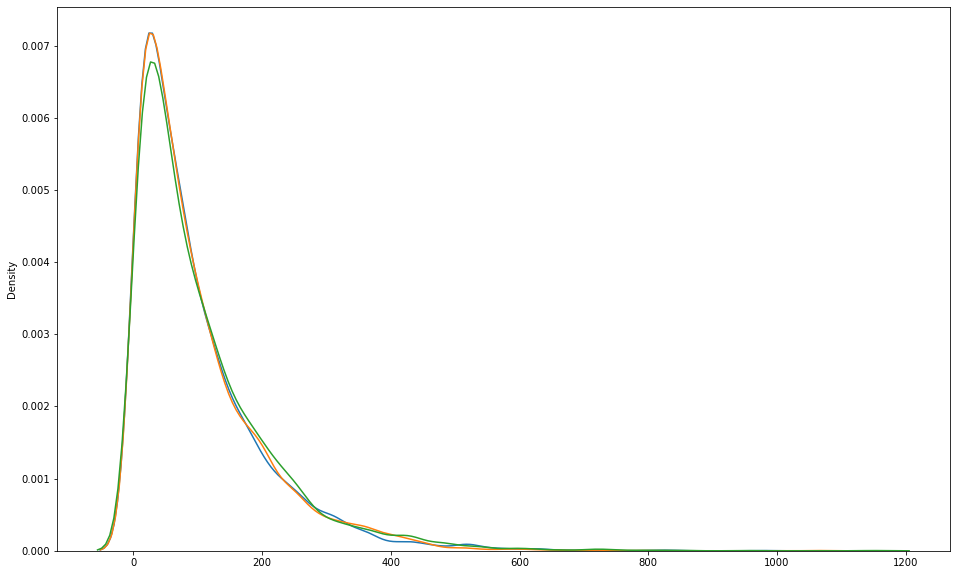

In [16]:
# посмотрим как выглядят значения, полученные в 3 выборках
plt.figure(figsize=(16,10))
sns.kdeplot(sample_1)
sns.kdeplot(sample_2_zero_effect)
sns.kdeplot(sample_2_with_effect)

## Проверим как ведут себя критерии с не совсем обычными распределениями (например, экспоненциальное с добавленными нулями. ARPU)

Представим, что у нас есть исторические данные по ARPU классифайда. Будем их использовать для симуляции эксперимента.

ARPU mean =  40.3923
ARPPU mean =  100.4034302759135
PU proportion =  0.4023
ARPU std =  79.67782376991731


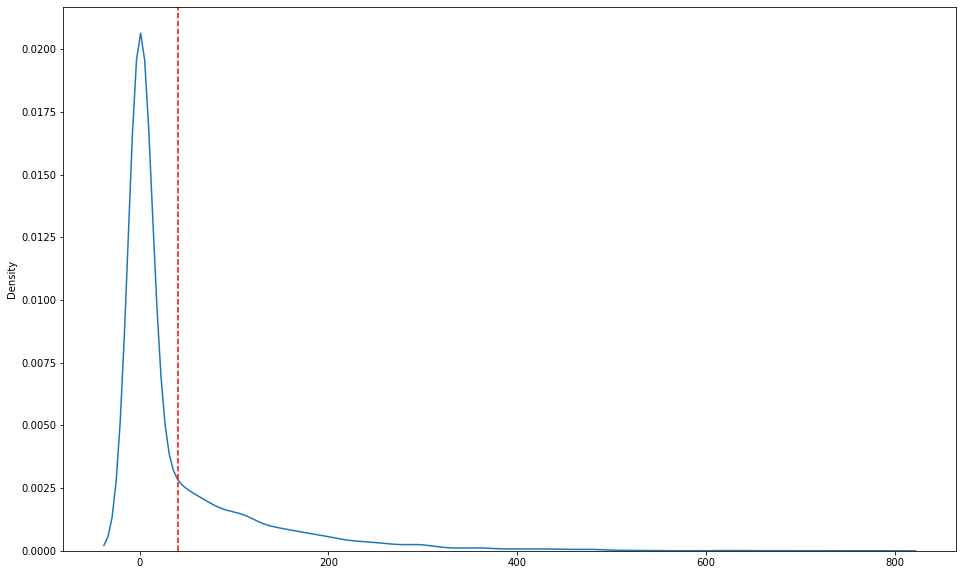

In [17]:
# создадим исторические данные по ARPU
hist_PU_proportion_sample = 0.4
hist_mean_ARPPU = 100
sample_size = 1000

all_non_zero_ARPU = np.random.exponential(scale = hist_mean_ARPPU, size = 10000) # сгенерируем данные по всем платящим
zero_ARPU_mask = np.random.binomial(1, hist_PU_proportion_sample , size = 10000) # создадим маску превращающую некоторых платящих в неплатящих
hist_final_ARPU = all_non_zero_ARPU * zero_ARPU_mask # наложим маску
hist_final_ARPU = np.round(hist_final_ARPU, 0) # округлим

hist_ARPU_mean = hist_final_ARPU.mean() # историческая средняя ARPU
hist_ARPU_std = hist_final_ARPU.std() # стандартное отклонение ARPU распределения

print('ARPU mean = ', hist_ARPU_mean)
print('ARPPU mean = ', hist_final_ARPU[hist_final_ARPU > 0].mean())
print('PU proportion = ', np.sum(hist_final_ARPU != 0) / 10000)
print('ARPU std = ', hist_ARPU_std)

# отрисуем полученное распределение
plt.figure(figsize=(16,10))
sns.kdeplot(hist_final_ARPU)
plt.axvline(x = hist_final_ARPU.mean(), linestyle = '--', color = 'red', label = 'ARPU mean')

## Проведем t-test влияния скидки на ARPU

Предположим что, мы хотим дать 5% скидку и надеемся, что вырастим ARPU на 10% за счет того, что подключится больше новых пользователей, которые раньше не платили. При этом те пользователи, которые платят, станут платить меньше в среднем на размер скидки (-5%).

Посмотрим как выглядят распределения этих двух возможных выборок ARPU.

Revenue hist_group =  403923.0
Revenue new_group =  432284.0


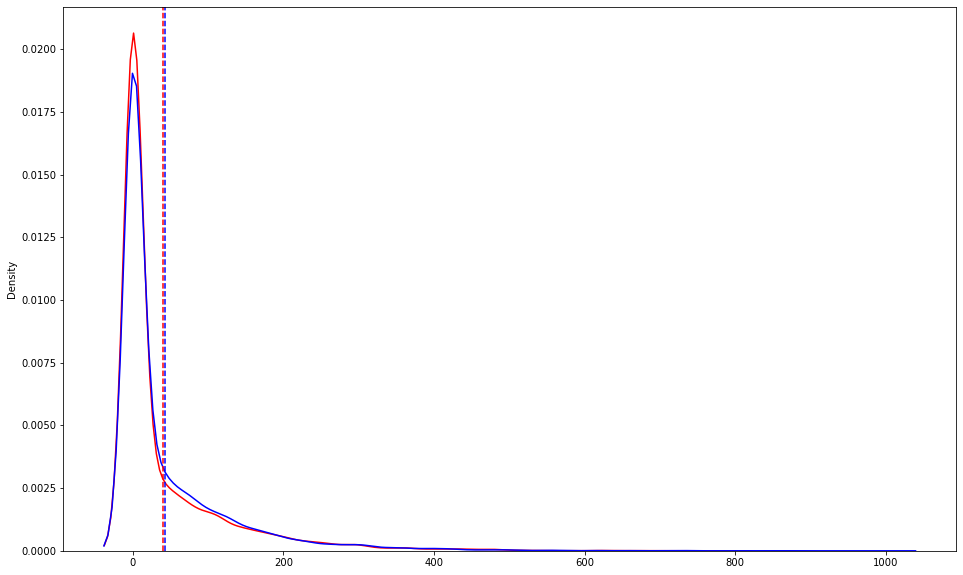

In [18]:
all_non_zero_ARPU_2_with_effect = np.random.exponential(scale = hist_mean_ARPPU*(1-0.05), size = 10000) # добавим эффект снижающий ARPPU (скидки -5%) 
zero_ARPU_mask_2_with_effect = np.random.binomial(1, 0.46 , size = 10000) # но увеличим процент платящих до 46%
final_ARPU_2_with_effect = all_non_zero_ARPU_2_with_effect * zero_ARPU_mask_2_with_effect
final_ARPU_2_with_effect = np.round(final_ARPU_2_with_effect, 0)

# отрисуем историческое распределение ARPU и полученное после скидок
plt.figure(figsize=(16,10))
sns.kdeplot(hist_final_ARPU, color = 'red')
sns.kdeplot(final_ARPU_2_with_effect, color = 'blue')
plt.axvline(x = hist_final_ARPU.mean(), linestyle = '--', color = 'red', label = 'hist_ARPU mean')
plt.axvline(x = final_ARPU_2_with_effect.mean(), linestyle = '--', color = 'blue', label = 'ARPU mean')

# отпринтуем суммарную выручку полученную по двум группам
print('Revenue hist_group = ', hist_final_ARPU.sum())
print('Revenue new_group = ', final_ARPU_2_with_effect.sum())

Определим нужный размер выборки для t-test

In [19]:
# определим нужный размер выборки
MDE = 0.1
alpha = 0.05
power = 0.8
effect_size = hist_ARPU_mean * MDE / hist_ARPU_std
sample_size = int(tt_ind_solve_power(effect_size = effect_size, alpha = alpha, power = power, nobs1 = None, ratio = 1))
print('Historical ARPU mean =', hist_ARPU_mean)
print('Historical ARPU std =', hist_ARPU_std)
print('Effect size = ', effect_size)
print('Sample size = ', sample_size)

Historical ARPU mean = 40.3923
Historical ARPU std = 79.67782376991731
Effect size =  0.050694532165737036
Sample size =  6109


In [20]:
# для симуляции эффекта зададим прирост процента платящих и размер скидки
PU_proportion_sample_1 = 0.4
PU_proportion_sample_2 = 0.463
discount = 0.05
mean_ARPPU_1 = hist_mean_ARPPU
mean_ARPPU_2 = mean_ARPPU_1*(1-discount)

print('historical ARPPU =', mean_ARPPU_1)
print('expected new ARPPU with discount =', mean_ARPPU_2)
print('expected new PU proportion =', PU_proportion_sample_2)

historical ARPPU = 100
expected new ARPPU with discount = 95.0
expected new PU proportion = 0.463


Number of simulations =  1000
Historical mean = 40.3923 Historical std = 79.67782376991731
Effect size =  0.050694532165737036
Sample size =  6109
Estimated absolute effect = 4.03923
Median means lift for AA simulation =  0.08733016860369602
Alpha(FPR) =  0.053
Alpha 95% CI: (0.03911451622486782, 0.06688548377513218)
Median means lift for AB simulation =  3.9454902602717326
Power(TPR) =  0.778
Beta 95% CI: (0.7522418672711898, 0.8037581327288102)


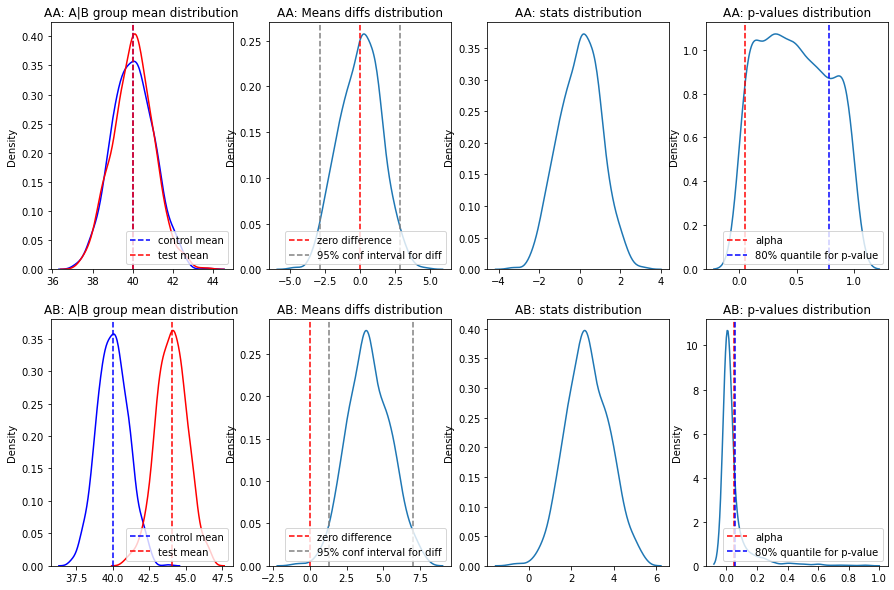

In [21]:
# определим дизайн теста

MDE = 0.1
alpha = 0.05
power = 0.8
effect_size = hist_ARPU_mean * MDE / hist_ARPU_std
sample_size = int(tt_ind_solve_power(effect_size = effect_size, alpha = alpha, power = power, nobs1 = None, ratio = 1))
n_iter = 1000
print('Number of simulations = ', n_iter)
print('Historical mean =', hist_ARPU_mean, 'Historical std =', hist_ARPU_std)
print('Effect size = ', effect_size)
print('Sample size = ', sample_size)
print('Estimated absolute effect =', hist_ARPU_mean * MDE )

aa_control_group_means = []
aa_test_group_means = []
ab_control_group_means = []
ab_test_group_means = []

aa_p_val_list = []
aa_t_stat_list = []
aa_means_diffs_list = []

ab_p_val_list = []
ab_t_stat_list = []
ab_means_diffs_list = []


for i in range(n_iter):
    # создаем контрольную выборку
    all_non_zero_ARPU_1 = np.random.exponential(scale = hist_mean_ARPPU, size = sample_size)
    zero_ARPU_mask_1 = np.random.binomial(1, PU_proportion_sample_1 , size = sample_size)
    final_ARPU_1 = all_non_zero_ARPU_1 * zero_ARPU_mask_1
    final_ARPU_1 = np.round(final_ARPU_1, 0)
        
    # создаем тестовую выборку без эффекта
    all_non_zero_ARPU_1_zero_effect = np.random.exponential(scale = hist_mean_ARPPU, size = sample_size)
    zero_ARPU_mask_1_zero_effect = np.random.binomial(1, PU_proportion_sample_1, size = sample_size)
    final_ARPU_1_zero_effect = all_non_zero_ARPU_1_zero_effect * zero_ARPU_mask_1_zero_effect
    final_ARPU_1_zero_effect = np.round(final_ARPU_1_zero_effect, 0)
    
    # создаем тестовую выборку с эффектом
    all_non_zero_ARPU_2_with_effect = np.random.exponential(scale = hist_mean_ARPPU*(1-discount), size = sample_size)
    zero_ARPU_mask_2_with_effect = np.random.binomial(1, PU_proportion_sample_2 , size = sample_size)
    final_ARPU_2_with_effect = all_non_zero_ARPU_2_with_effect * zero_ARPU_mask_2_with_effect
    final_ARPU_2_with_effect = np.round(final_ARPU_2_with_effect, 0)
        
    # рассчитываем нужные метрики
    aa_control_group_means.append(final_ARPU_1.mean())
    aa_test_group_means.append(final_ARPU_1_zero_effect.mean())
    
    ab_control_group_means.append(final_ARPU_1.mean())
    ab_test_group_means.append(final_ARPU_2_with_effect.mean())
    
    aa_means_diff = final_ARPU_1_zero_effect.mean() - final_ARPU_1.mean()
    ab_means_diff = final_ARPU_2_with_effect.mean() - final_ARPU_1.mean()
    
    aa_t_stat, aa_p_val = ttest_ind(final_ARPU_1_zero_effect, final_ARPU_1)
    ab_t_stat, ab_p_val = ttest_ind(final_ARPU_2_with_effect, final_ARPU_1)
    
    aa_p_val_list.append(aa_p_val)
    ab_p_val_list.append(ab_p_val)
    
    aa_t_stat_list.append(aa_t_stat)
    ab_t_stat_list.append(ab_t_stat)
    
    aa_means_diffs_list.append(aa_means_diff)
    ab_means_diffs_list.append(ab_means_diff)
    
experiment_simulation_plot(alpha = 0.05,
                           aa_control_group_means = aa_control_group_means,
                           aa_test_group_means = aa_test_group_means,
                           aa_means_diffs_list = aa_means_diffs_list,
                           aa_stat_list = aa_t_stat_list,
                           aa_p_val_list = aa_p_val_list,
                           ab_control_group_means = ab_control_group_means,
                           ab_test_group_means = ab_test_group_means,
                           ab_means_diffs_list = ab_means_diffs_list,
                           ab_stat_list = ab_t_stat_list,
                           ab_p_val_list = ab_p_val_list)

T-test и тут справляется хорошо. Выдерживает нужную альфа и бета.

Попробуем сделать ту же симуляцию, но с критерием Манна-Уитни. Посмотрим не сломается ли.

Number of simulations =  1000
Historical mean = 40.3923 Historical std = 79.67782376991731
Effect size =  0.050694532165737036
Sample size =  6109
Estimated absolute effect = 4.03923
Median means lift for AA simulation =  0.012195121951219079
Alpha(FPR) =  0.043
Alpha 95% CI: (0.03042701817664624, 0.055572981823353754)
Median means lift for AB simulation =  3.9709445081028
Power(TPR) =  1.0
Beta 95% CI: (1.0, 1.0)


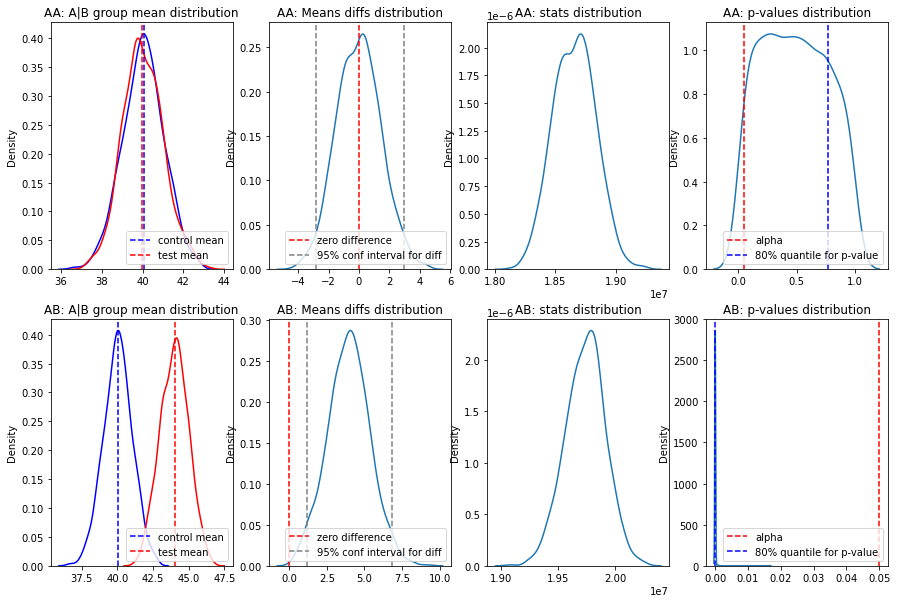

In [22]:
# определим дизайн теста

MDE = 0.1
alpha = 0.05
power = 0.8
effect_size = hist_ARPU_mean * MDE / hist_ARPU_std
sample_size = int(tt_ind_solve_power(effect_size = effect_size, alpha = alpha, power = power, nobs1 = None, ratio = 1))
n_iter = 1000
print('Number of simulations = ', n_iter)
print('Historical mean =', hist_ARPU_mean, 'Historical std =', hist_ARPU_std)
print('Effect size = ', effect_size)
print('Sample size = ', sample_size)
print('Estimated absolute effect =', hist_ARPU_mean * MDE)

aa_control_group_means = []
aa_test_group_means = []
ab_control_group_means = []
ab_test_group_means = []

aa_p_val_list = []
aa_u_stat_list = []
aa_means_diffs_list = []

ab_p_val_list = []
ab_u_stat_list = []
ab_means_diffs_list = []

for i in range(n_iter):
    # создаем контрольную выборку
    all_non_zero_ARPU_1 = np.random.exponential(scale = hist_mean_ARPPU, size = sample_size)
    zero_ARPU_mask_1 = np.random.binomial(1, PU_proportion_sample_1 , size = sample_size)
    final_ARPU_1 = all_non_zero_ARPU_1 * zero_ARPU_mask_1
    final_ARPU_1 = np.round(final_ARPU_1, 0)
        
    # создаем тестовую выборку без эффекта
    all_non_zero_ARPU_1_zero_effect = np.random.exponential(scale = hist_mean_ARPPU, size = sample_size)
    zero_ARPU_mask_1_zero_effect = np.random.binomial(1, PU_proportion_sample_1, size = sample_size)
    final_ARPU_1_zero_effect = all_non_zero_ARPU_1_zero_effect * zero_ARPU_mask_1_zero_effect
    final_ARPU_1_zero_effect = np.round(final_ARPU_1_zero_effect, 0)
    
    # создаем тестовую выборку с эффектом
    all_non_zero_ARPU_2_with_effect = np.random.exponential(scale = hist_mean_ARPPU*(1-discount), size = sample_size)
    zero_ARPU_mask_2_with_effect = np.random.binomial(1, PU_proportion_sample_2 , size = sample_size)
    final_ARPU_2_with_effect = all_non_zero_ARPU_2_with_effect * zero_ARPU_mask_2_with_effect
    final_ARPU_2_with_effect = np.round(final_ARPU_2_with_effect, 0)
        
    # рассчитываем нужные метрики
    aa_control_group_means.append(final_ARPU_1.mean())
    aa_test_group_means.append(final_ARPU_1_zero_effect.mean())
    
    ab_control_group_means.append(final_ARPU_1.mean())
    ab_test_group_means.append(final_ARPU_2_with_effect.mean())
    
    aa_means_diff = final_ARPU_1_zero_effect.mean() - final_ARPU_1.mean()
    ab_means_diff = final_ARPU_2_with_effect.mean() - final_ARPU_1.mean()
    
    aa_u_stat, aa_p_val = mannwhitneyu(final_ARPU_1_zero_effect, final_ARPU_1)
    ab_u_stat, ab_p_val = mannwhitneyu(final_ARPU_2_with_effect, final_ARPU_1)
        
    aa_p_val_list.append(aa_p_val)
    ab_p_val_list.append(ab_p_val)
    
    aa_u_stat_list.append(aa_u_stat)
    ab_u_stat_list.append(ab_u_stat)
    
    aa_means_diffs_list.append(aa_means_diff)
    ab_means_diffs_list.append(ab_means_diff)
    
experiment_simulation_plot(alpha = 0.05,
                           aa_control_group_means = aa_control_group_means,
                           aa_test_group_means = aa_test_group_means,
                           aa_means_diffs_list = aa_means_diffs_list,
                           aa_stat_list = aa_u_stat_list,
                           aa_p_val_list = aa_p_val_list,
                           
                           ab_control_group_means = ab_control_group_means,
                           ab_test_group_means = ab_test_group_means,
                           ab_means_diffs_list = ab_means_diffs_list,
                           ab_stat_list = ab_u_stat_list,
                           ab_p_val_list = ab_p_val_list)

Критерий Манна-Уитни конкретно для этого распределения смог показать более высокую мощность.

 Попробуем через симуляции определить, какая выборка нам была бы достаточна для достижения 80% мощности в тесте.

In [23]:
# создадим функцию проводящую одну итерацию Манна-Уитни теста по заданным гиперпараметрам
# и возвращающую p-value для АА-теста и АВ-теста

def simulate_one_arpu_mw_aab_test(h0_ARPPU, h1_ARPPU, h0_PU_prop, h1_PU_prop, sample_size):
    '''
    функция проводящая один Манна_Уитни тест на ARPU с заданными параметрами
    h0_ARPPU - ARPPU в контрольной выборке
    h1_ARPPU - ARPPU в тестовой выборке
    h0_PU_prop - процент платящих в контрольной выборке
    h1_PU_prop - процент платящих в тестовой выборке
    sample_size - размер выборки в тесте
    '''
    # создаем контрольную выборку
    all_non_zero_ARPU_1 = np.random.exponential(scale = h0_ARPPU, size = sample_size)
    zero_ARPU_mask_1 = np.random.binomial(1, h0_PU_prop , size = sample_size)
    final_ARPU_1 = all_non_zero_ARPU_1 * zero_ARPU_mask_1
    final_ARPU_1 = np.round(final_ARPU_1, 0)

    # создаем тестовую выборку без эффекта
    all_non_zero_ARPU_1_zero_effect = np.random.exponential(scale = h0_ARPPU, size = sample_size)
    zero_ARPU_mask_1_zero_effect = np.random.binomial(1, h0_PU_prop, size = sample_size)
    final_ARPU_1_zero_effect = all_non_zero_ARPU_1_zero_effect * zero_ARPU_mask_1_zero_effect
    final_ARPU_1_zero_effect = np.round(final_ARPU_1_zero_effect, 0)

    # создаем тестовую выборку с эффектом
    all_non_zero_ARPU_2_with_effect = np.random.exponential(scale = h1_ARPPU, size = sample_size)
    zero_ARPU_mask_2_with_effect = np.random.binomial(1, h1_PU_prop , size = sample_size)
    final_ARPU_2_with_effect = all_non_zero_ARPU_2_with_effect * zero_ARPU_mask_2_with_effect
    final_ARPU_2_with_effect = np.round(final_ARPU_2_with_effect, 0)
        
    # рассчитываем нужные метрики
    aa_means_diff = final_ARPU_1_zero_effect.mean() - final_ARPU_1.mean()
    ab_means_diff = final_ARPU_2_with_effect.mean() - final_ARPU_1.mean()
    
    _, aa_p_val = mannwhitneyu(final_ARPU_1_zero_effect, final_ARPU_1)
    _, ab_p_val = mannwhitneyu(final_ARPU_2_with_effect, final_ARPU_1)
    
    return(aa_means_diff, ab_means_diff, aa_p_val, ab_p_val)

In [24]:
# создадим функцию проводящую одну итерацию T-теста по заданным гиперпараметрам
# и возвращающую p-value для АА-теста и АВ-теста
# параметры те же самые, что и для предыдущей функции

def simulate_one_arpu_ttest_aab_test(h0_ARPPU, h1_ARPPU, h0_PU_prop, h1_PU_prop, sample_size):
    
    # создаем контрольную выборку
    all_non_zero_ARPU_1 = np.random.exponential(scale = h0_ARPPU, size = sample_size)
    zero_ARPU_mask_1 = np.random.binomial(1, h0_PU_prop , size = sample_size)
    final_ARPU_1 = all_non_zero_ARPU_1 * zero_ARPU_mask_1
    final_ARPU_1 = np.round(final_ARPU_1, 0)

    # создаем тестовую выборку без эффекта
    all_non_zero_ARPU_1_zero_effect = np.random.exponential(scale = h0_ARPPU, size = sample_size)
    zero_ARPU_mask_1_zero_effect = np.random.binomial(1, h0_PU_prop, size = sample_size)
    final_ARPU_1_zero_effect = all_non_zero_ARPU_1_zero_effect * zero_ARPU_mask_1_zero_effect
    final_ARPU_1_zero_effect = np.round(final_ARPU_1_zero_effect, 0)

    # создаем тестовую выборку с эффектом
    all_non_zero_ARPU_2_with_effect = np.random.exponential(scale = h1_ARPPU, size = sample_size)
    zero_ARPU_mask_2_with_effect = np.random.binomial(1, h1_PU_prop , size = sample_size)
    final_ARPU_2_with_effect = all_non_zero_ARPU_2_with_effect * zero_ARPU_mask_2_with_effect
    final_ARPU_2_with_effect = np.round(final_ARPU_2_with_effect, 0)
        
    # рассчитываем нужные метрики
    aa_means_diff = final_ARPU_1_zero_effect.mean() - final_ARPU_1.mean()
    ab_means_diff = final_ARPU_2_with_effect.mean() - final_ARPU_1.mean()
    
    aa_t_stat, aa_p_val = ttest_ind(final_ARPU_1_zero_effect, final_ARPU_1)
    ab_t_stat, ab_p_val = ttest_ind(final_ARPU_2_with_effect, final_ARPU_1)
    
    return(aa_means_diff, ab_means_diff, aa_p_val, ab_p_val)

In [28]:
simulate_one_arpu_ttest_aab_test(100, 95, 0.4, 0.46, 100)

(-15.990000000000002,
 -2.5600000000000023,
 0.20162184247783504,
 0.8330332431457168)

In [30]:
# прогоним циклом такой тест многократно, чтобы понять уровень альфа и бета в n_sim симмуляциях
# для удобства создадим функцию для этого. 

def get_alpha_beta_many_arpu_aab_tests(h0_ARPPU, h1_ARPPU, h0_PU_prop, h1_PU_prop, sample_size, n_sim, test_type):
    '''
    функция проводящая многократно тесты на ARPU с заданными параметрами
    h0_ARPPU - ARPPU в контрольной выборке
    h1_ARPPU - ARPPU в тестовой выборке
    h0_PU_prop - процент платящих в контрольной выборке
    h1_PU_prop - процент платящих в тестовой выборке
    sample_size - размер выборки в тесте
    n_sim - кол-во симуляций
    test_type - ['mw', 'tt'] реализация под 2 стат критерия Манна-Уитни и Т-тест
    output - возвращает alpha, beta и 95%-доверительные интервалы 
    '''
    aa_means_diff_list = []
    ab_means_diff_list = []
    aa_p_val_list = []
    ab_p_val_list = []

    for i in range(n_sim):
        if test_type == 'mw':
            aa_means_diff, ab_means_diff, aa_p_val, ab_p_val = simulate_one_arpu_mw_aab_test(h0_ARPPU, h1_ARPPU, h0_PU_prop, h1_PU_prop, sample_size)
        else:
            aa_means_diff, ab_means_diff, aa_p_val, ab_p_val = simulate_one_arpu_ttest_aab_test(h0_ARPPU, h1_ARPPU, h0_PU_prop, h1_PU_prop, sample_size)
        aa_means_diff_list.append(aa_means_diff)
        ab_means_diff_list.append(ab_means_diff)
        aa_p_val_list.append(aa_p_val)
        ab_p_val_list.append(ab_p_val)
    
    alpha = np.sum(np.array(aa_p_val_list) < 0.05) / n_sim
    beta = np.sum(np.array(ab_p_val_list) < 0.05) / n_sim
    
    alpha_ci = proportion_confint(np.sum(np.array(aa_p_val_list) < 0.05), n_sim, alpha=0.05)
    beta_ci = proportion_confint(np.sum(np.array(ab_p_val_list) < 0.05), n_sim, alpha=0.05)
    
    output = {'alpha':alpha, 'beta': beta, 'alpha_ci':alpha_ci, 'beta_ci':beta_ci}
    
    return(output)

In [35]:
# прогоним симуляцию на выборке 1000 наблюдений и с 500 симуляциями с тестом Манна-Уитни
output = get_alpha_beta_many_arpu_aab_tests(100, 95, 0.4, 0.46, 1000, 500, test_type = 'tt')

In [36]:
print('Alpha:', output['alpha'])
print('Power:', output['beta'])

Alpha: 0.034
Power: 0.156


Циклом прогоним и посмотрим, как ведут себя ошибки первого и второго рода при росте размера выборки в нашем конкретном кейсе

In [37]:
sample_size_list = np.arange(100, 8000, 100) # зададим линейное пространство размера выборок, по которому мы будем перебирать

mw_alphas_list = []
mw_betas_list = []
mw_lower_beta_ci_list = []
mw_upper_beta_ci_list = []

tt_alphas_list = []
tt_betas_list = []
tt_lower_beta_ci_list = []
tt_upper_beta_ci_list = []

# прогоним циклом, где для каждого размера выборки мы численно находим мощность и другие параметры
for i in sample_size_list:
    mw_output = get_alpha_beta_many_arpu_aab_tests(100, 80, 0.4, 0.46, i, 200, test_type = 'mw')
    mw_alpha = mw_output['alpha']
    mw_beta = mw_output['beta']
    mw_alpha_ci = mw_output['alpha_ci']
    mw_beta_ci = mw_output['beta_ci']
    mw_alphas_list.append(mw_alpha)
    mw_betas_list.append(mw_beta)
    mw_lower_beta_ci_list.append(mw_beta_ci[0])
    mw_upper_beta_ci_list.append(mw_beta_ci[1])
    
    tt_output = get_alpha_beta_many_arpu_aab_tests(100, 80, 0.4, 0.46, i, 200, test_type = 'ttest')
    tt_alpha = tt_output['alpha']
    tt_beta = tt_output['beta']
    tt_alpha_ci = tt_output['alpha_ci']
    tt_beta_ci = tt_output['beta_ci']
    tt_alphas_list.append(tt_alpha)
    tt_betas_list.append(tt_beta)
    tt_lower_beta_ci_list.append(tt_beta_ci[0])
    tt_upper_beta_ci_list.append(tt_beta_ci[1])

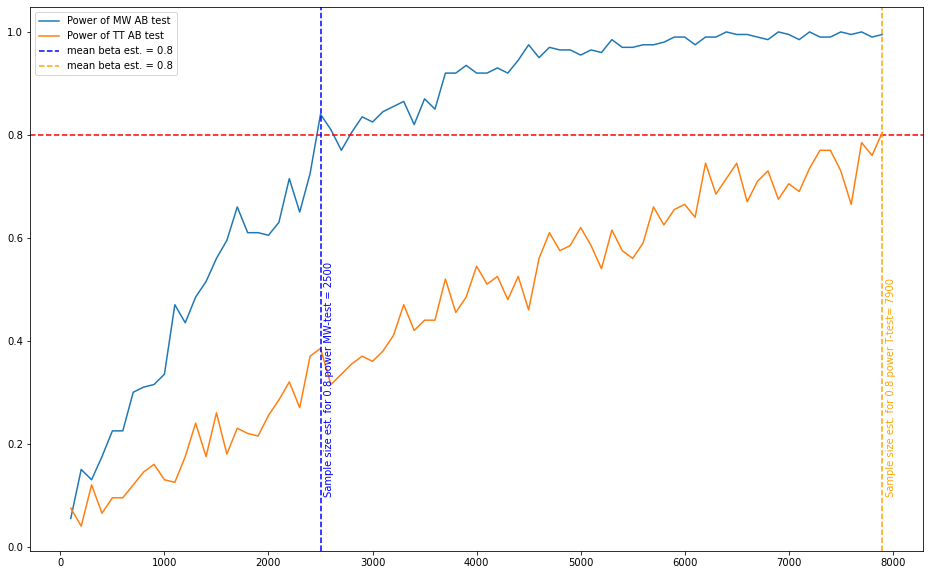

In [39]:
# Отрисуем результаты симуляции, полученные на прошлом этапе. Посмотрим рост мощности теста.
mw_beta_est_index = np.argmax(np.array(mw_betas_list) >= 0.8)
tt_beta_est_index = np.argmax(np.array(tt_betas_list) >= 0.8)


plt.figure(figsize=(16,10))
sns.lineplot(x = sample_size_list, y = mw_betas_list, label = 'Power of MW AB test')
sns.lineplot(x = sample_size_list, y = tt_betas_list, label = 'Power of TT AB test')

plt.axhline(0.8, color = 'red', linestyle ='--')
plt.axvline(sample_size_list[mw_beta_est_index], color = 'blue', linestyle ='--', label = 'mean beta est. = 0.8')
plt.text(sample_size_list[mw_beta_est_index] + 30, 0.1, 'Sample size est. for 0.8 power MW-test = {}'.format(sample_size_list[mw_beta_est_index]), rotation = 'vertical', color = 'blue')
plt.axvline(sample_size_list[tt_beta_est_index], color = 'orange', linestyle ='--', label = 'mean beta est. = 0.8')
plt.text(sample_size_list[tt_beta_est_index] + 30, 0.1, 'Sample size est. for 0.8 power T-test= {}'.format(sample_size_list[tt_beta_est_index]), rotation = 'vertical', color = 'orange')

plt.legend()

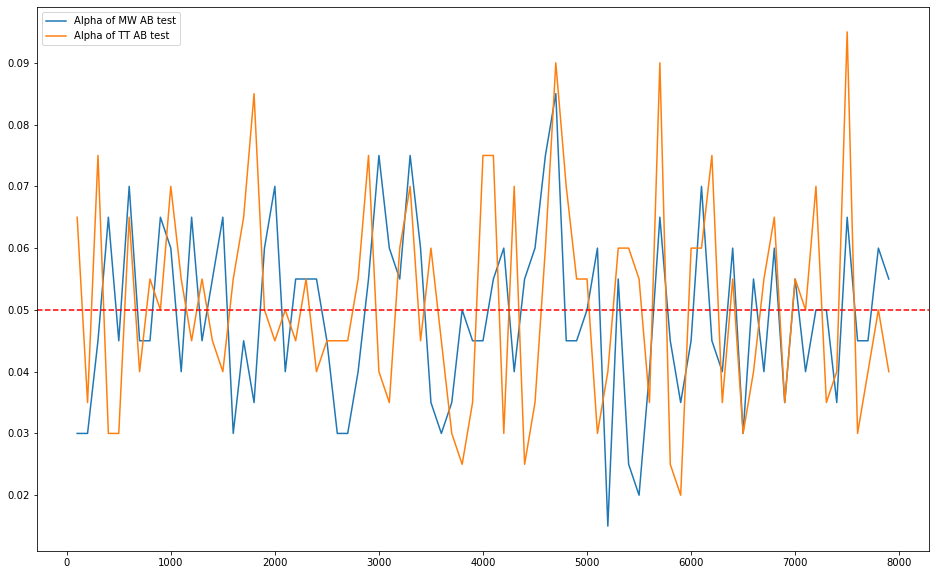

In [42]:
# посмотрим поведение ошибки alpha
plt.figure(figsize=(16,10))
sns.lineplot(x = sample_size_list, y = mw_alphas_list, label = 'Alpha of MW AB test')
sns.lineplot(x = sample_size_list, y = tt_alphas_list, label = 'Alpha of TT AB test')
plt.axhline(0.05, color = 'red', linestyle ='--')

#plt.fill_between(sample_size_list, lower_beta_ci_list, upper_beta_ci_list, color='blue', alpha=0.1) # отрисовываем ДИ 
plt.legend()

## Посмотрим на основную проблему теста Манна-Уитни

Давайте посмотрим на основной минус критерия Манна-Уитни. То, что его результаты надо использовать острожно, т.к. он может проверять не те гипотезы, которые вы держите у себя в голове. Он не смотрит на разницу средних, а вы ожидаете, что он проверяет именно это.

Прогоним тот же тест с ARPU, что выше, но сделаем так, чтобы ARPU на самом деле не различался в двух группах. Для это немного изменим прирост процента платящих.

Number of simulations =  1000
Historical mean = 40.3923 Historical std = 79.67782376991731
Effect size =  0.050694532165737036
Sample size =  6109
Estimated absolute effect = 4.03923
Median means lift for AA simulation =  -0.004256015714517503
Alpha(FPR) =  0.046
Alpha 95% CI: (0.033016218621397656, 0.05898378137860234)
Median means lift for AB simulation =  -0.13758389261745307
Power(TPR) =  0.384
Beta 95% CI: (0.3538557794049627, 0.4141442205950373)


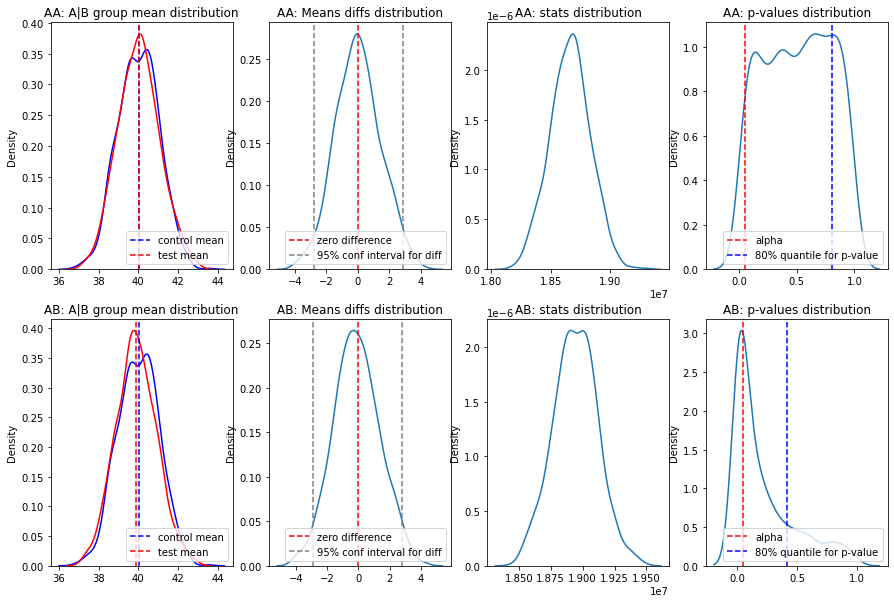

In [43]:
# определим дизайн теста

MDE = 0.1
alpha = 0.05
power = 0.8
effect_size = hist_ARPU_mean * MDE / hist_ARPU_std
sample_size = int(tt_ind_solve_power(effect_size = effect_size, alpha = alpha, power = power, nobs1 = None, ratio = 1))
n_iter = 1000
print('Number of simulations = ', n_iter)
print('Historical mean =', hist_ARPU_mean, 'Historical std =', hist_ARPU_std)
print('Effect size = ', effect_size)
print('Sample size = ', sample_size)
print('Estimated absolute effect =', hist_ARPU_mean * MDE)

aa_control_group_means = []
aa_test_group_means = []
ab_control_group_means = []
ab_test_group_means = []

aa_p_val_list = []
aa_u_stat_list = []
aa_means_diffs_list = []

ab_p_val_list = []
ab_u_stat_list = []
ab_means_diffs_list = []

for i in range(n_iter):
    # создаем контрольную выборку
    all_non_zero_ARPU_1 = np.random.exponential(scale = hist_mean_ARPPU, size = sample_size)
    zero_ARPU_mask_1 = np.random.binomial(1, PU_proportion_sample_1 , size = sample_size)
    final_ARPU_1 = all_non_zero_ARPU_1 * zero_ARPU_mask_1
    final_ARPU_1 = np.round(final_ARPU_1, 0)
        
    # создаем тестовую выборку без эффекта
    all_non_zero_ARPU_1_zero_effect = np.random.exponential(scale = hist_mean_ARPPU, size = sample_size)
    zero_ARPU_mask_1_zero_effect = np.random.binomial(1, PU_proportion_sample_1, size = sample_size)
    final_ARPU_1_zero_effect = all_non_zero_ARPU_1_zero_effect * zero_ARPU_mask_1_zero_effect
    final_ARPU_1_zero_effect = np.round(final_ARPU_1_zero_effect, 0)
    
    # создаем тестовую выборку с эффектом
    all_non_zero_ARPU_2_with_effect = np.random.exponential(scale = hist_mean_ARPPU*(1-discount), size = sample_size)
    zero_ARPU_mask_2_with_effect = np.random.binomial(1, 0.42 , size = sample_size) # эффект прироста процента платящих ниже, чем в предыдущем примере
    final_ARPU_2_with_effect = all_non_zero_ARPU_2_with_effect * zero_ARPU_mask_2_with_effect
    final_ARPU_2_with_effect = np.round(final_ARPU_2_with_effect, 0)
        
    # рассчитываем нужные метрики
    aa_control_group_means.append(final_ARPU_1.mean())
    aa_test_group_means.append(final_ARPU_1_zero_effect.mean())
    
    ab_control_group_means.append(final_ARPU_1.mean())
    ab_test_group_means.append(final_ARPU_2_with_effect.mean())
    
    aa_means_diff = final_ARPU_1_zero_effect.mean() - final_ARPU_1.mean()
    ab_means_diff = final_ARPU_2_with_effect.mean() - final_ARPU_1.mean()
    
    aa_u_stat, aa_p_val = mannwhitneyu(final_ARPU_1_zero_effect, final_ARPU_1)
    ab_u_stat, ab_p_val = mannwhitneyu(final_ARPU_2_with_effect, final_ARPU_1)
        
    aa_p_val_list.append(aa_p_val)
    ab_p_val_list.append(ab_p_val)
    
    aa_u_stat_list.append(aa_u_stat)
    ab_u_stat_list.append(ab_u_stat)
    
    aa_means_diffs_list.append(aa_means_diff)
    ab_means_diffs_list.append(ab_means_diff)
    
experiment_simulation_plot(alpha = 0.05,
                           aa_control_group_means = aa_control_group_means,
                           aa_test_group_means = aa_test_group_means,
                           aa_means_diffs_list = aa_means_diffs_list,
                           aa_stat_list = aa_u_stat_list,
                           aa_p_val_list = aa_p_val_list,
                           
                           ab_control_group_means = ab_control_group_means,
                           ab_test_group_means = ab_test_group_means,
                           ab_means_diffs_list = ab_means_diffs_list,
                           ab_stat_list = ab_u_stat_list,
                           ab_p_val_list = ab_p_val_list)

Как мы видим, здесь несмотря на то, что по-настоящему средние ARPU не различаются, критерий все равно довольно часто в ~40% случаев отлавливает какой-то эффект. Критерий смотрит на другие изменения в распределении рангов. Рост процента платящих на 2% выше влияет на ранговое распределение, что критерий и замечает.

Посмотрим, как t-test отработает этот кейс.

Number of simulations =  1000
Historical mean = 39.9052 Historical std = 79.65433329681443
Effect size =  0.05009796497988629
Sample size =  6255
Estimated absolute effect = 3.99052
Median means lift for AA simulation =  -0.041167066346922354
Alpha(FPR) =  0.054
Alpha 95% CI: (0.039991535330510385, 0.06800846466948962)
Median means lift for AB simulation =  0.0008792965627506533
Power(TPR) =  0.058
Beta 95% CI: (0.043512697141032626, 0.07248730285896737)


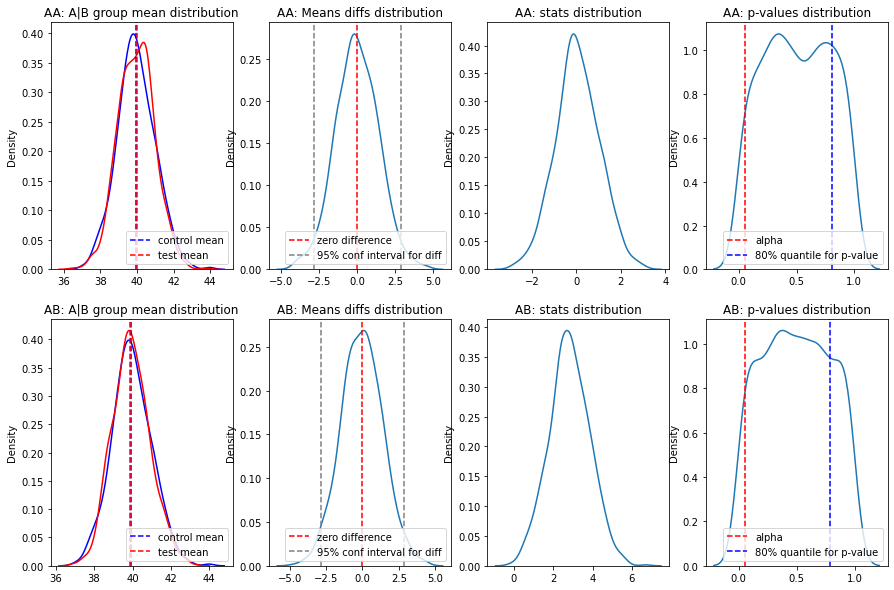

In [85]:
# определим дизайн теста

MDE = 0.1
alpha = 0.05
power = 0.8
effect_size = hist_ARPU_mean * MDE / hist_ARPU_std
sample_size = int(tt_ind_solve_power(effect_size = effect_size, alpha = alpha, power = power, nobs1 = None, ratio = 1))
n_iter = 1000
print('Number of simulations = ', n_iter)
print('Historical mean =', hist_ARPU_mean, 'Historical std =', hist_ARPU_std)
print('Effect size = ', effect_size)
print('Sample size = ', sample_size)
print('Estimated absolute effect =', hist_ARPU_mean * MDE)

aa_control_group_means = []
aa_test_group_means = []
ab_control_group_means = []
ab_test_group_means = []

aa_p_val_list = []
aa_u_stat_list = []
aa_means_diffs_list = []

ab_p_val_list = []
ab_u_stat_list = []
ab_means_diffs_list = []

for i in range(n_iter):
    # создаем контрольную выборку
    all_non_zero_ARPU_1 = np.random.exponential(scale = hist_mean_ARPPU, size = sample_size)
    zero_ARPU_mask_1 = np.random.binomial(1, PU_proportion_sample_1 , size = sample_size)
    final_ARPU_1 = all_non_zero_ARPU_1 * zero_ARPU_mask_1
    final_ARPU_1 = np.round(final_ARPU_1, 0)
        
    # создаем тестовую выборку без эффекта
    all_non_zero_ARPU_1_zero_effect = np.random.exponential(scale = hist_mean_ARPPU, size = sample_size)
    zero_ARPU_mask_1_zero_effect = np.random.binomial(1, PU_proportion_sample_1, size = sample_size)
    final_ARPU_1_zero_effect = all_non_zero_ARPU_1_zero_effect * zero_ARPU_mask_1_zero_effect
    final_ARPU_1_zero_effect = np.round(final_ARPU_1_zero_effect, 0)
    
    # создаем тестовую выборку с эффектом
    all_non_zero_ARPU_2_with_effect = np.random.exponential(scale = hist_mean_ARPPU*(1-discount), size = sample_size)
    zero_ARPU_mask_2_with_effect = np.random.binomial(1, 0.42 , size = sample_size) # зде
    final_ARPU_2_with_effect = all_non_zero_ARPU_2_with_effect * zero_ARPU_mask_2_with_effect
    final_ARPU_2_with_effect = np.round(final_ARPU_2_with_effect, 0)
        
    # рассчитываем нужные метрики
    aa_control_group_means.append(final_ARPU_1.mean())
    aa_test_group_means.append(final_ARPU_1_zero_effect.mean())
    
    ab_control_group_means.append(final_ARPU_1.mean())
    ab_test_group_means.append(final_ARPU_2_with_effect.mean())
    
    aa_means_diff = final_ARPU_1_zero_effect.mean() - final_ARPU_1.mean()
    ab_means_diff = final_ARPU_2_with_effect.mean() - final_ARPU_1.mean()
    
    aa_t_stat, aa_p_val = ttest_ind(final_ARPU_1_zero_effect, final_ARPU_1)
    ab_t_stat, ab_p_val = ttest_ind(final_ARPU_2_with_effect, final_ARPU_1)
        
    aa_p_val_list.append(aa_p_val)
    ab_p_val_list.append(ab_p_val)
    
    aa_u_stat_list.append(aa_u_stat)
    ab_u_stat_list.append(ab_u_stat)
    
    aa_means_diffs_list.append(aa_means_diff)
    ab_means_diffs_list.append(ab_means_diff)
    
experiment_simulation_plot(alpha = 0.05,
                           aa_control_group_means = aa_control_group_means,
                           aa_test_group_means = aa_test_group_means,
                           aa_means_diffs_list = aa_means_diffs_list,
                           aa_stat_list = aa_t_stat_list,
                           aa_p_val_list = aa_p_val_list,
                           
                           ab_control_group_means = ab_control_group_means,
                           ab_test_group_means = ab_test_group_means,
                           ab_means_diffs_list = ab_means_diffs_list,
                           ab_stat_list = ab_t_stat_list,
                           ab_p_val_list = ab_p_val_list)

t-test отработал здесь так, как и ожидалось. Он проигнорировал рост процента платящих и ошибся в оценке эффекта на средний ARPU только в 5% случаев. Т.е. несмотря на то, что он именно в этом кейсе показывает меньшую мощность и ему нужна большая выборка, он проверяет гипотезу о средней корректно. В то время как Манн-Уитни чаще бы нам врал.

# Попробуем посмотреть, как ведет себя t-test критерий для выборок с разной дисперсией (критерий Уэлча).

Effect size = 0.1
Estimated absolute effect = 5.0
Number of simulations =  1000
Sample size =  1570
Median means lift for AA simulation =  0.028299917346927828
Alpha(FPR) =  0.048
Alpha 95% CI: (0.0347508754149401, 0.061249124585059905)
Median means lift for AB simulation =  4.990474170306626
Power(TPR) =  0.618
Beta 95% CI: (0.5878856141926456, 0.6481143858073544)


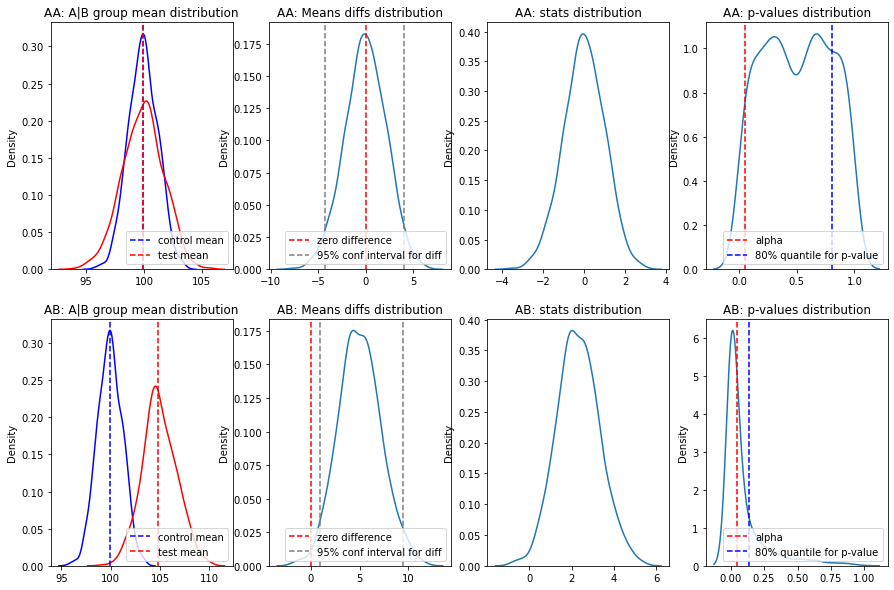

In [96]:
# определим дизайн теста
alpha = 0.05
beta = 0.2
std_1 = 50
std_2 = 70
mean = 100
power = 1 - beta
rel_lift = 0.05
abs_lift = mean*rel_lift #
effect_size = abs_lift / std_1

print('Effect size =', effect_size)
print('Estimated absolute effect =', abs_lift)

n_iter = 1000
print('Number of simulations = ', n_iter)

sample_size = int(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, ratio=1))
print('Sample size = ', sample_size)

aa_control_group_means = []
aa_test_group_means = []
ab_control_group_means = []
ab_test_group_means = []

aa_p_val_list = []
aa_t_stat_list = []
aa_means_diffs_list = []

ab_p_val_list = []
ab_t_stat_list = []
ab_means_diffs_list = []

for i in range(n_iter):
    sample_1 = np.random.normal(mean, std_1, sample_size)
    sample_2_zero_effect = np.random.normal(mean*(1+0), std_2, sample_size)
    sample_2_with_effect = np.random.normal(mean*(1+rel_lift), std_2, sample_size)
    
    aa_control_group_means.append(sample_1.mean())
    aa_test_group_means.append(sample_2_zero_effect.mean())
    
    ab_control_group_means.append(sample_1.mean())
    ab_test_group_means.append(sample_2_with_effect.mean())

    aa_means_diff = sample_2_zero_effect.mean() - sample_1.mean()
    ab_means_diff = sample_2_with_effect.mean() - sample_1.mean()
    
    aa_t_stat, aa_p_val = ttest_ind(sample_2_zero_effect, sample_1, equal_var=True)
    ab_t_stat, ab_p_val = ttest_ind(sample_2_with_effect, sample_1, equal_var=True)
    
    aa_p_val_list.append(aa_p_val)
    ab_p_val_list.append(ab_p_val)
    
    aa_t_stat_list.append(aa_t_stat)
    ab_t_stat_list.append(ab_t_stat)
    
    aa_means_diffs_list.append(aa_means_diff)
    ab_means_diffs_list.append(ab_means_diff)
    
experiment_simulation_plot(alpha = 0.05,
                           aa_control_group_means = aa_control_group_means,
                           aa_test_group_means = aa_test_group_means,
                           aa_means_diffs_list = aa_means_diffs_list,
                           aa_stat_list = aa_t_stat_list,
                           aa_p_val_list = aa_p_val_list,
                           ab_control_group_means = ab_control_group_means,
                           ab_test_group_means = ab_test_group_means,
                           ab_means_diffs_list = ab_means_diffs_list,
                           ab_stat_list = ab_t_stat_list,
                           ab_p_val_list = ab_p_val_list)

Effect size = 0.1
Estimated absolute effect = 5.0
Number of simulations =  1000
Sample size =  1570
Median means lift for AA simulation =  0.021541116762719525
Alpha(FPR) =  0.036
Alpha 95% CI: (0.02445383237115583, 0.047546167628844165)
Median means lift for AB simulation =  5.011789892034592
Power(TPR) =  0.632
Beta 95% CI: (0.6021096817233111, 0.6618903182766889)


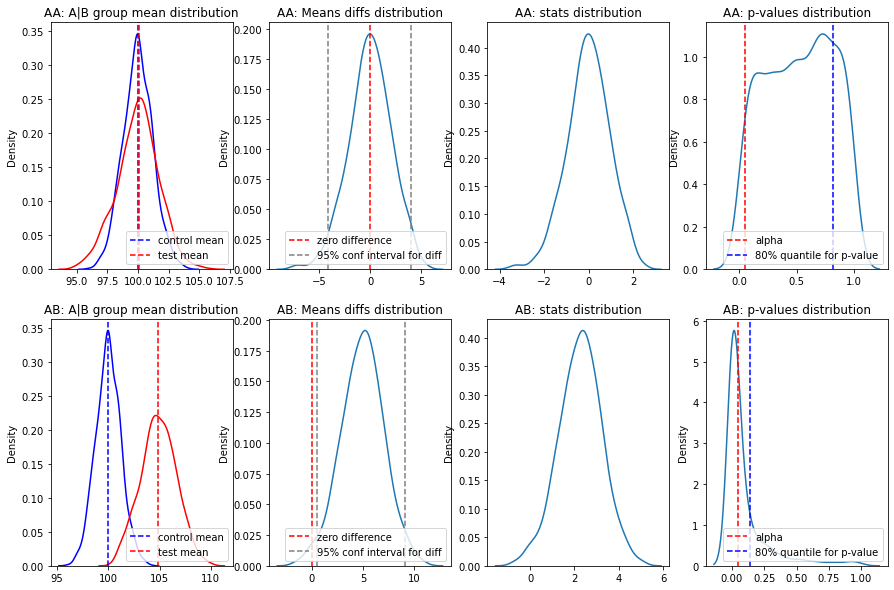

In [98]:
# определим дизайн теста
alpha = 0.05
beta = 0.2
std_1 = 50
std_2 = 70
mean = 100
power = 1 - beta
rel_lift = 0.05
abs_lift = mean*rel_lift #
effect_size = abs_lift / std_1

print('Effect size =', effect_size)
print('Estimated absolute effect =', abs_lift)

n_iter = 1000
print('Number of simulations = ', n_iter)

sample_size = int(tt_ind_solve_power(effect_size = effect_size, alpha = alpha, power = power, nobs1 = None, ratio = 1))
print('Sample size = ', sample_size)

aa_control_group_means = []
aa_test_group_means = []
ab_control_group_means = []
ab_test_group_means = []

aa_p_val_list = []
aa_t_stat_list = []
aa_means_diffs_list = []

ab_p_val_list = []
ab_t_stat_list = []
ab_means_diffs_list = []

for i in range(n_iter):
    sample_1 = np.random.normal(mean, std_1, sample_size)
    sample_2_zero_effect = np.random.normal(mean*(1+0), std_2, sample_size)
    sample_2_with_effect = np.random.normal(mean*(1+rel_lift), std_2, sample_size)
    
    aa_control_group_means.append(sample_1.mean())
    aa_test_group_means.append(sample_2_zero_effect.mean())
    
    ab_control_group_means.append(sample_1.mean())
    ab_test_group_means.append(sample_2_with_effect.mean())

    aa_means_diff = sample_2_zero_effect.mean() - sample_1.mean()
    ab_means_diff = sample_2_with_effect.mean() - sample_1.mean()
    
    aa_t_stat, aa_p_val = ttest_ind(sample_2_zero_effect, sample_1, equal_var=False)
    ab_t_stat, ab_p_val = ttest_ind(sample_2_with_effect, sample_1, equal_var=False)
    
    aa_p_val_list.append(aa_p_val)
    ab_p_val_list.append(ab_p_val)
    
    aa_t_stat_list.append(aa_t_stat)
    ab_t_stat_list.append(ab_t_stat)
    
    aa_means_diffs_list.append(aa_means_diff)
    ab_means_diffs_list.append(ab_means_diff)
    
experiment_simulation_plot(alpha = 0.05,
                           aa_control_group_means = aa_control_group_means,
                           aa_test_group_means = aa_test_group_means,
                           aa_means_diffs_list = aa_means_diffs_list,
                           aa_stat_list = aa_t_stat_list,
                           aa_p_val_list = aa_p_val_list,
                           ab_control_group_means = ab_control_group_means,
                           ab_test_group_means = ab_test_group_means,
                           ab_means_diffs_list = ab_means_diffs_list,
                           ab_stat_list = ab_t_stat_list,
                           ab_p_val_list = ab_p_val_list)

Как мы видим, мощность сильно не меняется при использовании критерия Уэлча. На самом деле проблема в том, что мы использовали формулу для расчета размера выборок, предполагающих одинаковую дисперсию. Для получения достаточной мощности нам на этапе продумывания дизайна нужно было бы понимать, что стандартные отклонения в выборках будут разные и поэтому размер эффекта посчитался бы в меньшую сторону. И для его проверки нам понадобилась бы большая выборка.

Здесь хорошим правилом будет проводить установочные исследования, где вы проводите оценку параметров распределения в выборке 1 и в выборке 2, либо по историческим экспериментам прикидываете ожидаемые значения. И после этого формируете дизайн теста.

## Посмотрим, поможет ли улучшить мощность критерий Манна-Уитни.

Effect size = 0.1
Estimated absolute effect = 5.0
Number of simulations =  1000
Sample size =  1570
Median means lift for AA simulation =  -0.1320908004368775
Alpha(FPR) =  0.049
Alpha 95% CI: (0.03562060765260524, 0.062379392347394765)
Median means lift for AB simulation =  4.899828278666959
Power(TPR) =  0.6
Beta 95% CI: (0.5696363685148401, 0.6303636314851598)


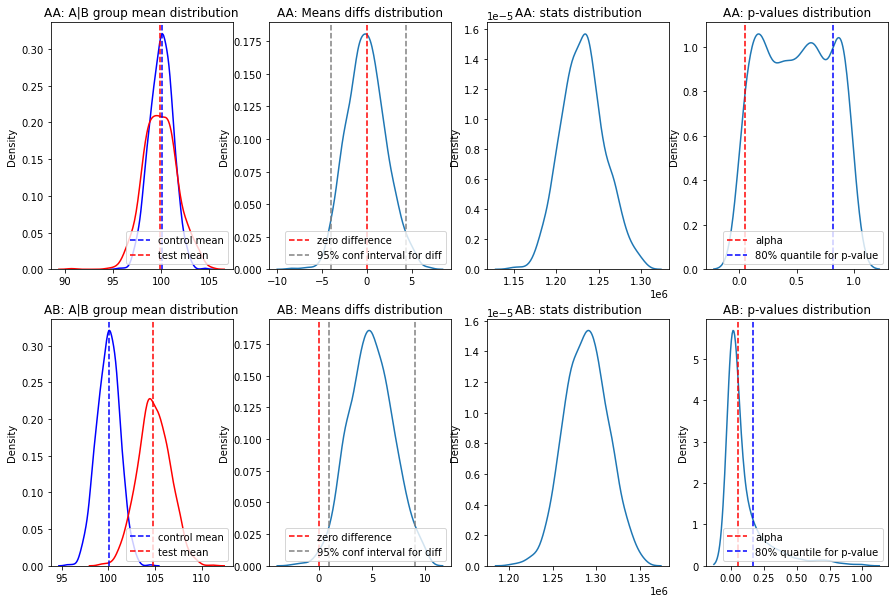

In [99]:
# определим дизайн теста
alpha = 0.05
beta = 0.2
std_1 = 50
std_2 = 70
mean = 100
power = 1 - beta
rel_lift = 0.05
abs_lift = mean*rel_lift #
effect_size = abs_lift / std_1

print('Effect size =', effect_size)
print('Estimated absolute effect =', abs_lift)

n_iter = 1000
print('Number of simulations = ', n_iter)

sample_size = int(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, ratio=1))
print('Sample size = ', sample_size)

aa_control_group_means = []
aa_test_group_means = []
ab_control_group_means = []
ab_test_group_means = []

aa_p_val_list = []
aa_u_stat_list = []
aa_means_diffs_list = []

ab_p_val_list = []
ab_u_stat_list = []
ab_means_diffs_list = []

for i in range(n_iter):
    sample_1 = np.random.normal(mean, std_1, sample_size)
    sample_2_zero_effect = np.random.normal(mean*(1+0), std_2, sample_size)
    sample_2_with_effect = np.random.normal(mean*(1+rel_lift), std_2, sample_size)
    
    aa_control_group_means.append(sample_1.mean())
    aa_test_group_means.append(sample_2_zero_effect.mean())
    
    ab_control_group_means.append(sample_1.mean())
    ab_test_group_means.append(sample_2_with_effect.mean())

    aa_means_diff = sample_2_zero_effect.mean() - sample_1.mean()
    ab_means_diff = sample_2_with_effect.mean() - sample_1.mean()
    
    aa_u_stat, aa_p_val = mannwhitneyu(sample_2_zero_effect, sample_1)
    ab_u_stat, ab_p_val = mannwhitneyu(sample_2_with_effect, sample_1)
    
    aa_p_val_list.append(aa_p_val)
    ab_p_val_list.append(ab_p_val)
    
    aa_u_stat_list.append(aa_u_stat)
    ab_u_stat_list.append(ab_u_stat)
    
    aa_means_diffs_list.append(aa_means_diff)
    ab_means_diffs_list.append(ab_means_diff)
    
experiment_simulation_plot(alpha = 0.05,
                           aa_control_group_means = aa_control_group_means,
                           aa_test_group_means = aa_test_group_means,
                           aa_means_diffs_list = aa_means_diffs_list,
                           aa_stat_list = aa_u_stat_list,
                           aa_p_val_list = aa_p_val_list,
                           ab_control_group_means = ab_control_group_means,
                           ab_test_group_means = ab_test_group_means,
                           ab_means_diffs_list = ab_means_diffs_list,
                           ab_stat_list = ab_u_stat_list,
                           ab_p_val_list = ab_p_val_list)

Как мы видим, мощность сильно не меняется.

## Давайте проверим еще один критерий, который сравнивает только медианы (Moods median-test).

Effect size = 0.1
Estimated absolute effect = 5.0
Number of simulations =  1000
Sample size =  1570
Median means lift for AA simulation =  0.035394671177499504
Alpha(FPR) =  0.049
Alpha 95% CI: (0.03562060765260524, 0.062379392347394765)
Median means lift for AB simulation =  4.985866466268675
Power(TPR) =  0.628
Beta 95% CI: (0.5980429266473629, 0.6579570733526371)


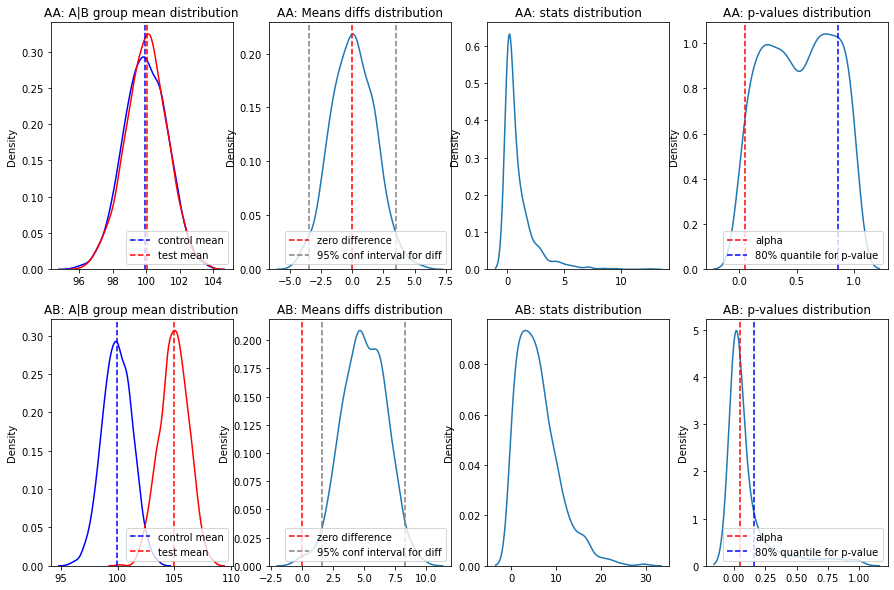

In [414]:
# определим дизайн теста
alpha = 0.05
beta = 0.2
std_1 = 50
mean = 100
power = 1 - beta
rel_lift = 0.05
abs_lift = mean*rel_lift #
effect_size = abs_lift / std_1

print('Effect size =', effect_size)
print('Estimated absolute effect =', abs_lift)

n_iter = 1000
print('Number of simulations = ', n_iter)

sample_size = int(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, ratio=1))
print('Sample size = ', sample_size)

aa_control_group_means = []
aa_test_group_means = []
ab_control_group_means = []
ab_test_group_means = []

aa_p_val_list = []
aa_m_stat_list = []
aa_means_diffs_list = []

ab_p_val_list = []
ab_m_stat_list = []
ab_means_diffs_list = []

for i in range(n_iter):
    sample_1 = np.random.normal(mean, std_1, sample_size)
    sample_2_zero_effect = np.random.normal(mean*(1+0), std_1, sample_size)
    sample_2_with_effect = np.random.normal(mean*(1+rel_lift), std_1, sample_size)
    
    aa_control_group_means.append(sample_1.mean())
    aa_test_group_means.append(sample_2_zero_effect.mean())
    
    ab_control_group_means.append(sample_1.mean())
    ab_test_group_means.append(sample_2_with_effect.mean())

    aa_means_diff = sample_2_zero_effect.mean() - sample_1.mean()
    ab_means_diff = sample_2_with_effect.mean() - sample_1.mean()
    
    aa_m_stat = median_test(sample_2_zero_effect, sample_1, correction = True)[0] # медманный тест проверяющий гипотезу о равенствое медиан
    aa_p_val = median_test(sample_2_zero_effect, sample_1, correction = True)[1]
    
    ab_m_stat = median_test(sample_2_with_effect, sample_1, correction = True)[0]
    ab_p_val = median_test(sample_2_with_effect, sample_1, correction = True)[1]
    
    aa_p_val_list.append(aa_p_val)
    ab_p_val_list.append(ab_p_val)
    
    aa_m_stat_list.append(aa_m_stat)
    ab_m_stat_list.append(ab_m_stat)
    
    aa_means_diffs_list.append(aa_means_diff)
    ab_means_diffs_list.append(ab_means_diff)
    
experiment_simulation_plot(alpha = 0.05,
                           aa_control_group_means = aa_control_group_means,
                           aa_test_group_means = aa_test_group_means,
                           aa_means_diffs_list = aa_means_diffs_list,
                           aa_stat_list = aa_m_stat_list,
                           aa_p_val_list = aa_p_val_list,
                           ab_control_group_means = ab_control_group_means,
                           ab_test_group_means = ab_test_group_means,
                           ab_means_diffs_list = ab_means_diffs_list,
                           ab_stat_list = ab_m_stat_list,
                           ab_p_val_list = ab_p_val_list)

Как мы видим у Moods median test уровень мощности ниже чем у t-test и Манна-Уитни. Но в целом, если хотите проверить гипотезу именно о равенстве медиан, его вполне можно использовать. Но понадобятся большие выборки. Выборки для этого теста аналитически рассчитать не получится. Предлагаем сделать это численно через симуляции так, как мы это делали в примере с ARPU.

# Summary по критериям

- Критерии заточены под конкретные гипотезы
- t-test работает достаточно хорошо, но чувствителен к появлению выбросов
- Манна-Уитни test также работает не плохо, но плохо интерпретируем и может проверять не ту гипотезу, о которой вы думаете. Из-за этого увеличивается доля ложноположительных ответов в вашей команде. С ним нужно быть аккуратным.
- Мощность часто зависит от того, удалось ли вам на этапе дизайна правильно определить размер выборки (это не всегда возможно)
- Старайтесь перепроверять свои критерии через симуляции на реально существующих данных